# Brain Tumor Detection and Analysis Pipeline

This notebook covers the process of preprocessing MRI images, training multiple CNN models for brain tumor classification (Glioma, Meningioma, Pituitary, No Tumor), comparing their performance, and deploying the best model in an interactive Gradio web application with Grad-CAM visualization.

## Phase 1: Setup, Preprocessing, and Data Loading

In [1]:
# ===============================
# PHASE 1.1: DRIVE MOUNT & IMPORTS
# ===============================
from google.colab import drive
import os
import cv2
import numpy as np
from tqdm.notebook import tqdm # Use notebook tqdm for better Colab display
import shutil

print("⏳ Mounting Google Drive...")
drive.mount('/content/drive')

# Define paths relative to your Drive structure
# Adapt these paths if your folder structure is different
BASE_DRIVE_PATH = '/content/drive/MyDrive'
PROJECT_FOLDER = os.path.join(BASE_DRIVE_PATH, 'tuxpaint') # Main project folder

INPUT_TRAIN_DATA_PATH = os.path.join(PROJECT_FOLDER, 'Training')
INPUT_TEST_DATA_PATH = os.path.join(PROJECT_FOLDER, 'Testing')

OUTPUT_TRAIN_PREPROCESSED_PATH = os.path.join(PROJECT_FOLDER, 'train_preprocessed')
OUTPUT_TEST_PREPROCESSED_PATH = os.path.join(PROJECT_FOLDER, 'test_preprocessed')

# Ensure project and output directories exist
os.makedirs(PROJECT_FOLDER, exist_ok=True)
os.makedirs(OUTPUT_TRAIN_PREPROCESSED_PATH, exist_ok=True)
os.makedirs(OUTPUT_TEST_PREPROCESSED_PATH, exist_ok=True)

print(f"📁 Project Folder: {PROJECT_FOLDER}")
print(f"💾 Raw Train Data: {INPUT_TRAIN_DATA_PATH}")
print(f"💾 Raw Test Data: {INPUT_TEST_DATA_PATH}")
print(f"💿 Preprocessed Train Output: {OUTPUT_TRAIN_PREPROCESSED_PATH}")
print(f"💿 Preprocessed Test Output: {OUTPUT_TEST_PREPROCESSED_PATH}")

⏳ Mounting Google Drive...
Mounted at /content/drive
📁 Project Folder: /content/drive/MyDrive/tuxpaint
💾 Raw Train Data: /content/drive/MyDrive/tuxpaint/Training
💾 Raw Test Data: /content/drive/MyDrive/tuxpaint/Testing
💿 Preprocessed Train Output: /content/drive/MyDrive/tuxpaint/train_preprocessed
💿 Preprocessed Test Output: /content/drive/MyDrive/tuxpaint/test_preprocessed


In [2]:
# ===============================
# PHASE 1.2: PREPROCESSING FUNCTION
# ===============================

# Constants for preprocessing
IMAGE_SIZE = 224 # Target image size for models

def preprocess_image_clahe(img_path, output_size=IMAGE_SIZE):
    """ Reads, preprocesses (CLAHE, resize), and returns an image """
    try:
        img = cv2.imread(img_path, cv2.IMREAD_COLOR) # Read as color image
        if img is None:
            print(f"⚠️ Warning: Could not read image {img_path}. Skipping.")
            return None

        # Ensure image is 3 channels (convert grayscale if necessary)
        if len(img.shape) == 2 or img.shape[2] == 1:
           img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

        # Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
        # Convert to LAB color space, apply CLAHE to L channel, convert back
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        cl = clahe.apply(l)
        limg = cv2.merge((cl, a, b))
        img_clahe = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)

        # Resize image
        img_resized = cv2.resize(img_clahe, (output_size, output_size))

        return img_resized

    except Exception as e:
        print(f"❌ Error processing image {img_path}: {e}")
        return None

def process_and_save_dataset(input_dir, output_dir):
    """ Processes all images in input_dir and saves to output_dir """
    count = 0
    if not os.path.isdir(input_dir):
         print(f"❌ Error: Input directory not found: {input_dir}")
         return 0

    print(f"⚙️ Processing images from: {input_dir}")
    for class_label in tqdm(os.listdir(input_dir), desc="Processing Classes"):
        class_input_path = os.path.join(input_dir, class_label)
        class_output_path = os.path.join(output_dir, class_label)

        if not os.path.isdir(class_input_path):
            print(f"ℹ️ Skipping non-directory item: {class_label}")
            continue

        os.makedirs(class_output_path, exist_ok=True) # Ensure output class folder exists

        image_files = [f for f in os.listdir(class_input_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'))]
        for img_name in tqdm(image_files, desc=f"Class {class_label}", leave=False):
            img_input_path = os.path.join(class_input_path, img_name)
            img_output_path = os.path.join(class_output_path, img_name)

            processed_img = preprocess_image_clahe(img_input_path)

            if processed_img is not None:
                # Save the processed image (ensure filename is valid)
                try:
                    cv2.imwrite(img_output_path, processed_img)
                    count += 1
                except Exception as e:
                     # Try cleaning filename if imwrite fails (e.g., due to special chars)
                     clean_img_name = "".join(c if c.isalnum() or c in ('.', '_', '-') else '_' for c in img_name)
                     if clean_img_name != img_name:
                          img_output_path_cleaned = os.path.join(class_output_path, clean_img_name)
                          print(f"⚠️ Retrying save with cleaned filename: {clean_img_name}")
                          try:
                               cv2.imwrite(img_output_path_cleaned, processed_img)
                               count += 1
                          except Exception as e2:
                               print(f"❌ Error saving even cleaned image {img_output_path_cleaned}: {e2}")
                     else:
                          print(f"❌ Error saving image {img_output_path}: {e}")

    print(f"✅ Saved {count} preprocessed images to: {output_dir}")
    return count

# Run preprocessing for Train and Test sets
print("--- Preprocessing Training Data ---")
train_count = process_and_save_dataset(INPUT_TRAIN_DATA_PATH, OUTPUT_TRAIN_PREPROCESSED_PATH)

print("\n--- Preprocessing Testing Data ---")
test_count = process_and_save_dataset(INPUT_TEST_DATA_PATH, OUTPUT_TEST_PREPROCESSED_PATH)

if train_count > 0 and test_count > 0:
    print("\n✅ Preprocessing completed for both datasets.")
else:
    print("\n⚠️ Preprocessing might have encountered issues. Please check logs.")

--- Preprocessing Training Data ---
⚙️ Processing images from: /content/drive/MyDrive/tuxpaint/Training


Processing Classes:   0%|          | 0/4 [00:00<?, ?it/s]

Class pituitary:   0%|          | 0/1457 [00:00<?, ?it/s]

Class meningioma:   0%|          | 0/1339 [00:00<?, ?it/s]

Class glioma:   0%|          | 0/1321 [00:00<?, ?it/s]

...

Class notumor:   0%|          | 0/405 [00:00<?, ?it/s]

Class pituitary:   0%|          | 0/300 [00:00<?, ?it/s]

Class meningioma:   0%|          | 0/306 [00:00<?, ?it/s]

Class glioma:   0%|          | 0/300 [00:00<?, ?it/s]

✅ Saved 1311 preprocessed images to: /content/drive/MyDrive/tuxpaint/test_preprocessed

✅ Preprocessing completed for both datasets.


## Phase 2: Data Augmentation and Generators

📁 Loading training data from: /content/drive/MyDrive/tuxpaint/train_preprocessed
Found 5712 images belonging to 4 classes.

📁 Loading validation data from: /content/drive/MyDrive/tuxpaint/test_preprocessed
Found 1311 images belonging to 4 classes.

📊 Class Indices (Training Generator):
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

📊 Class Indices (Validation Generator):
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

🔢 Number of classes detected: 4

🖼️ Displaying sample augmented images...


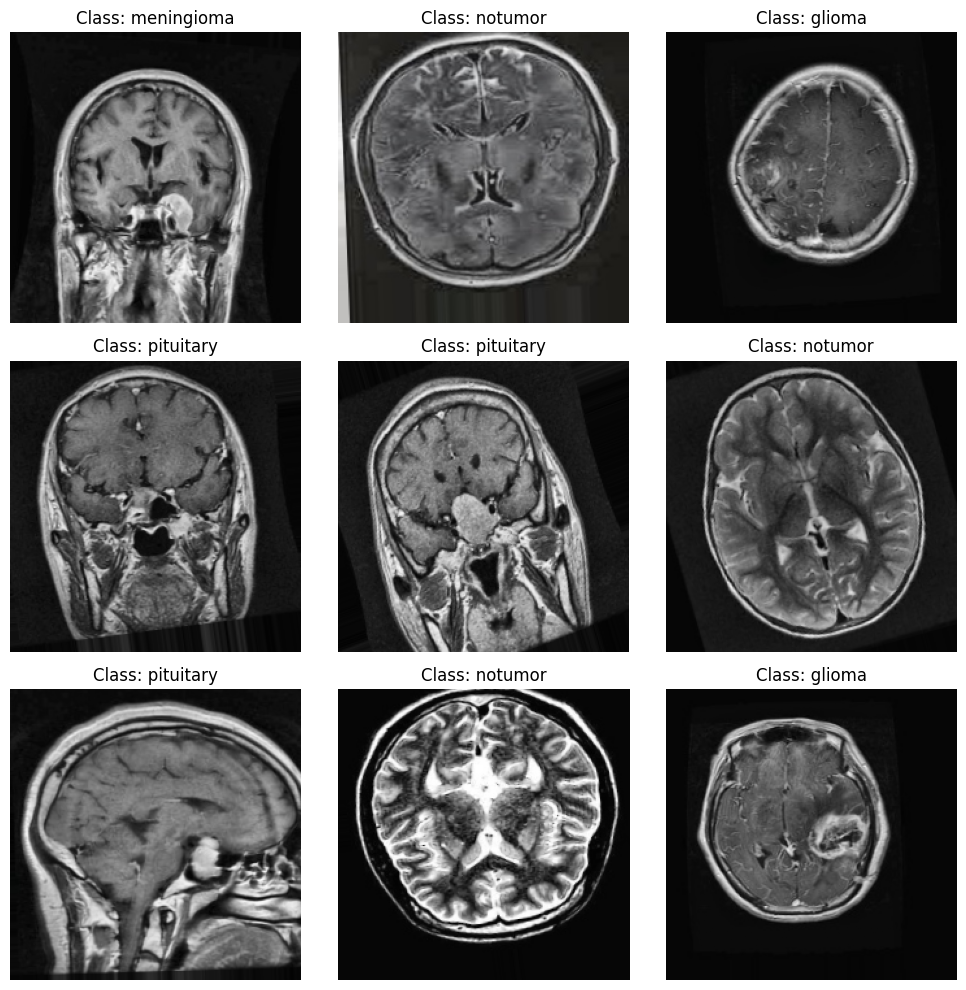

✅ Data generators created successfully.


In [3]:
# ===============================
# PHASE 2: DATA AUGMENTATION & GENERATORS
# ===============================
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import matplotlib.pyplot as plt
import numpy as np

# Config
IMAGE_SIZE = 224
BATCH_SIZE = 32
SEED = 42 # for reproducibility

# Paths to preprocessed data
TRAIN_DIR = OUTPUT_TRAIN_PREPROCESSED_PATH
VAL_DIR = OUTPUT_TEST_PREPROCESSED_PATH # Using the preprocessed test set as validation

# --- Create ImageDataGenerators --- #

# Training Generator with Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,         # Normalize pixel values to [0, 1]
    rotation_range=20,      # Random rotation up to 20 degrees
    width_shift_range=0.1,  # Random horizontal shift up to 10%
    height_shift_range=0.1, # Random vertical shift up to 10%
    shear_range=0.1,        # Shear intensity
    zoom_range=0.1,         # Random zoom up to 10%
    horizontal_flip=True,   # Randomly flip images horizontally
    fill_mode='nearest'     # Strategy for filling new pixels
)

# Validation/Test Generator (only rescaling)
val_datagen = ImageDataGenerator(
    rescale=1./255
)

# --- Create Data Flows --- #

# Check if directories exist
if not os.path.isdir(TRAIN_DIR):
     print(f"❌ Error: Training directory not found: {TRAIN_DIR}")
elif not os.path.isdir(VAL_DIR):
     print(f"❌ Error: Validation directory not found: {VAL_DIR}")
else:
    print(f"📁 Loading training data from: {TRAIN_DIR}")
    train_gen = train_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=(IMAGE_SIZE, IMAGE_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical', # for multi-class classification
        seed=SEED,
        shuffle=True
    )

    print(f"\n📁 Loading validation data from: {VAL_DIR}")
    val_gen = val_datagen.flow_from_directory(
        VAL_DIR,
        target_size=(IMAGE_SIZE, IMAGE_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        seed=SEED,
        shuffle=False # No shuffling for validation/testing
    )

    # Print class indices - IMPORTANT for interpreting predictions later
    print("\n📊 Class Indices (Training Generator):")
    print(train_gen.class_indices)
    print("\n📊 Class Indices (Validation Generator):")
    print(val_gen.class_indices)

    NUM_CLASSES = len(train_gen.class_indices)
    print(f"\n🔢 Number of classes detected: {NUM_CLASSES}")

    # --- Visualize Sample Augmented Images (Optional) --- #
    print("\n🖼️ Displaying sample augmented images...")
    try:
        sample_batch_images, sample_batch_labels = next(train_gen)
        plt.figure(figsize=(10, 10))
        for i in range(min(9, BATCH_SIZE)): # Show up to 9 images
            plt.subplot(3, 3, i + 1)
            plt.imshow(sample_batch_images[i])
            # Find class name from index
            class_index = np.argmax(sample_batch_labels[i])
            class_name = list(train_gen.class_indices.keys())[class_index]
            plt.title(f"Class: {class_name}")
            plt.axis('off')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"❌ Could not display sample images: {e}")

    print("✅ Data generators created successfully.")

## Phase 3: Model Building and Training

In [4]:
# ===============================
# PHASE 3.1-3.3: UTILS - BUILD, TRAIN, PLOT
# ===============================
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
import tensorflow as tf

# === Build Transfer Learning Model ===
def build_transfer_model(base_model, name, num_classes):
    # Ensure base model output is suitable for GAP
    x = base_model.output
    # Add GlobalAveragePooling2D if the output is not already pooled
    if len(x.shape) > 2:
         x = GlobalAveragePooling2D()(x)

    # Add classification head
    x = Dropout(0.5)(x) # Increased dropout slightly
    out = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=out)

    # Freeze base model layers
    for layer in base_model.layers:
        layer.trainable = False

    print(f"📐 {name} Model Summary (Head Added):")
    # model.summary() # Keep summary concise for multiple models
    print(f"   Input shape: {model.input_shape}")
    print(f"   Output shape: {model.output_shape}")
    print(f"   Trainable params: {count_trainable_params(model)}")
    return model

def count_trainable_params(model):
    return sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])

# === Training Helper ===
def train_model(model, train_gen, val_gen, save_path, label, epochs, steps_per_epoch, validation_steps):
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), # Adam optimizer
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # Callbacks
    checkpoint = ModelCheckpoint(save_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1) # Stop if val_loss doesn't improve for 5 epochs

    print(f"\n🚀 Training {label} for up to {epochs} epochs (Early Stopping Enabled)...")
    # Ensure generators are reset before training
    train_gen.reset()
    val_gen.reset()
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        validation_steps=validation_steps,
        callbacks=[checkpoint, early_stopping],
        verbose=1
    )
    print(f"✅ Training {label} complete.")
    return history

# === Plot Results ===
def plot_history(hist, title):
    if not hist or not hist.history:
         print(f"No history data to plot for {title}")
         return
    epochs = range(1, len(hist.history.get('accuracy', [])) + 1)
    if not epochs:
        print(f"No epoch data found in history for {title}")
        return

    plt.figure(figsize=(12, 4))

    # Plot Accuracy
    if 'accuracy' in hist.history and 'val_accuracy' in hist.history:
        plt.subplot(1, 2, 1)
        plt.plot(epochs, hist.history['accuracy'], 'bo-', label='Train Acc') # Added markers
        plt.plot(epochs, hist.history['val_accuracy'], 'ro-', label='Val Acc') # Added markers
        plt.title(f"{title} Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.grid(True)
        plt.legend()
    else:
        print(f"Accuracy keys missing in history for {title}")


    # Plot Loss
    if 'loss' in hist.history and 'val_loss' in hist.history:
        plt.subplot(1, 2, 2)
        plt.plot(epochs, hist.history['loss'], 'bo-', label='Train Loss') # Added markers
        plt.plot(epochs, hist.history['val_loss'], 'ro-', label='Val Loss') # Added markers
        plt.title(f"{title} Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.grid(True)
        plt.legend()
    else:
        print(f"Loss keys missing in history for {title}")


    plt.tight_layout()
    plt.show()

print("✅ Utility functions defined.")

✅ Utility functions defined.



--- Training ResNet50 ---
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
📐 ResNet50 Model Summary (Head Added):
   Input shape: (None, 224, 224, 3)
   Output shape: (None, 4)
   Trainable params: 8196

🚀 Training ResNet50 for up to 15 epochs (Early Stopping Enabled)...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 554ms/step - accuracy: 0.2929 - loss: 1.5501
Epoch 1: val_accuracy improved from -inf to 0.48131, saving model to /content/drive/MyDrive/tuxpaint/resnet50_best.h5


179/179 ━━━━━━━━━━━━━━━━━━━━ 129s 637ms/step - accuracy: 0.2932 - loss: 1.5492 - val_accuracy: 0.4813 - val_loss: 1.2089
Epoch 2/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 528ms/step - accuracy: 0.4735 - loss: 1.1967
Epoch 2: val_accuracy improved from 0.48131 to 0.51487, saving model to /content/drive/MyDrive/tuxpaint/resnet50_best.h5


179/179 ━━━━━━━━━━━━━━━━━━━━ 121s 563ms/step - accuracy: 0.4735 - loss: 1.1966 - val_accuracy: 0.5149 - val_loss: 1.1368
Epoch 3/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.5222 - loss: 1.1103
Epoch 3: val_accuracy improved from 0.51487 to 0.55683, saving model to /content/drive/MyDrive/tuxpaint/resnet50_best.h5


179/179 ━━━━━━━━━━━━━━━━━━━━ 143s 568ms/step - accuracy: 0.5222 - loss: 1.1103 - val_accuracy: 0.5568 - val_loss: 1.0954
Epoch 4/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 517ms/step - accuracy: 0.5488 - loss: 1.0815
Epoch 4: val_accuracy did not improve from 0.55683
179/179 ━━━━━━━━━━━━━━━━━━━━ 98s 547ms/step - accuracy: 0.5488 - loss: 1.0815 - val_accuracy: 0.5324 - val_loss: 1.1020
Epoch 5/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 520ms/step - accuracy: 0.5578 - loss: 1.0519
Epoch 5: val_accuracy did not improve from 0.55683
179/179 ━━━━━━━━━━━━━━━━━━━━ 104s 579ms/step - accuracy: 0.5578 - loss: 1.0519 - val_accuracy: 0.5469 - val_loss: 1.0826
Epoch 6/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 518ms/step - accuracy: 0.5676 - loss: 1.0394
Epoch 6: val_accuracy did not improve from 0.55683
179/179 ━━━━━━━━━━━━━━━━━━━━ 98s 549ms/step - accuracy: 0.5676 - loss: 1.0393 - val_accuracy: 0.5362 - val_loss: 1.0792
Epoch 7/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 514ms/step - accuracy: 0.5712 - loss: 1.0133
Epoch 7: val_

179/179 ━━━━━━━━━━━━━━━━━━━━ 143s 551ms/step - accuracy: 0.5847 - loss: 0.9829 - val_accuracy: 0.5797 - val_loss: 1.0366
Epoch 10/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 523ms/step - accuracy: 0.5834 - loss: 0.9894
Epoch 10: val_accuracy did not improve from 0.57971
179/179 ━━━━━━━━━━━━━━━━━━━━ 99s 553ms/step - accuracy: 0.5834 - loss: 0.9894 - val_accuracy: 0.5545 - val_loss: 1.0705
Epoch 11/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 517ms/step - accuracy: 0.5984 - loss: 0.9713
Epoch 11: val_accuracy did not improve from 0.57971
179/179 ━━━━━━━━━━━━━━━━━━━━ 141s 546ms/step - accuracy: 0.5984 - loss: 0.9713 - val_accuracy: 0.5675 - val_loss: 1.0407
Epoch 12/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 515ms/step - accuracy: 0.5962 - loss: 0.9644
Epoch 12: val_accuracy improved from 0.57971 to 0.58810, saving model to /content/drive/MyDrive/tuxpaint/resnet50_best.h5


179/179 ━━━━━━━━━━━━━━━━━━━━ 147s 572ms/step - accuracy: 0.5962 - loss: 0.9644 - val_accuracy: 0.5881 - val_loss: 1.0099
Epoch 13/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 528ms/step - accuracy: 0.5960 - loss: 0.9586
Epoch 13: val_accuracy did not improve from 0.58810
179/179 ━━━━━━━━━━━━━━━━━━━━ 101s 562ms/step - accuracy: 0.5961 - loss: 0.9586 - val_accuracy: 0.5873 - val_loss: 1.0293
Epoch 14/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - accuracy: 0.6043 - loss: 0.9541
Epoch 14: val_accuracy did not improve from 0.58810
179/179 ━━━━━━━━━━━━━━━━━━━━ 102s 570ms/step - accuracy: 0.6043 - loss: 0.9541 - val_accuracy: 0.5721 - val_loss: 1.0469
Epoch 15/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 515ms/step - accuracy: 0.5904 - loss: 0.9486
Epoch 15: val_accuracy improved from 0.58810 to 0.59191, saving model to /content/drive/MyDrive/tuxpaint/resnet50_best.h5


179/179 ━━━━━━━━━━━━━━━━━━━━ 101s 565ms/step - accuracy: 0.5905 - loss: 0.9486 - val_accuracy: 0.5919 - val_loss: 1.0008
Restoring model weights from the end of the best epoch: 15.
✅ Training ResNet50 complete.


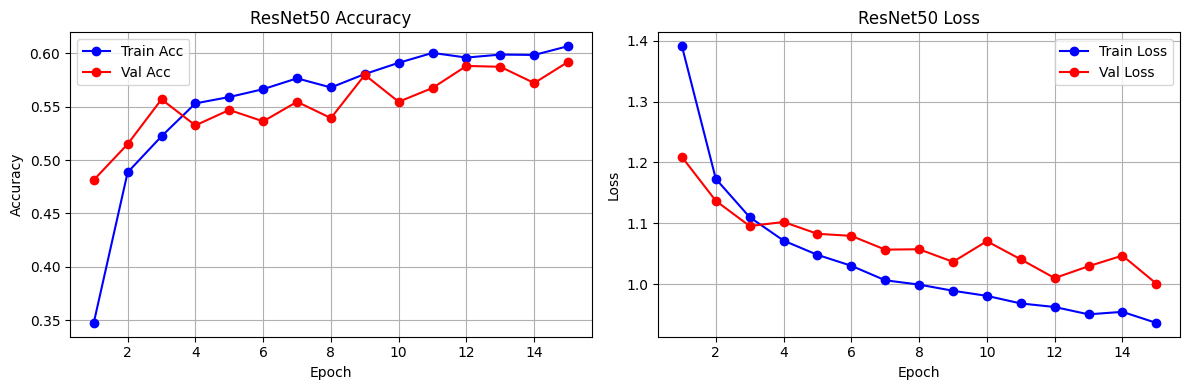

In [5]:
# ===============================
# PHASE 3.4: TRAIN RESNET50
# ===============================
from tensorflow.keras.applications import ResNet50
import os

# Config
EPOCHS_RESNET = 15 # Allow more epochs for larger models
STEPS = len(train_gen) if 'train_gen' in globals() else 50 # Use full generator steps if possible
VAL_STEPS = len(val_gen) if 'val_gen' in globals() else 20 # Use full generator steps if possible
IMAGE_SIZE = 224
NUM_CLASSES = len(train_gen.class_indices) if 'train_gen' in globals() else 4
BASE_MODEL_OUTPUT_DIR = PROJECT_FOLDER # Use main project folder for saving models

print("\n--- Training ResNet50 ---")
if 'train_gen' in globals() and 'val_gen' in globals():
    resnet_base = ResNet50(include_top=False, weights='imagenet', input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    resnet_model = build_transfer_model(resnet_base, "ResNet50", NUM_CLASSES)
    resnet_save_path = os.path.join(BASE_MODEL_OUTPUT_DIR, "resnet50_best.h5")
    resnet_history = train_model(resnet_model, train_gen, val_gen, resnet_save_path, "ResNet50", EPOCHS_RESNET, STEPS, VAL_STEPS)
    plot_history(resnet_history, "ResNet50")
else:
    print("❌ Cannot train ResNet50: Data generators ('train_gen', 'val_gen') not found.")


--- Training VGG16 (Fast) ---
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
📐 VGG16 Model Summary (Head Added):
   Input shape: (None, 224, 224, 3)
   Output shape: (None, 4)
   Trainable params: 2052

🚀 Training VGG16 for up to 8 epochs (Early Stopping Enabled)...
Epoch 1/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 532ms/step - accuracy: 0.2515 - loss: 1.4825
Epoch 1: val_accuracy improved from -inf to 0.44063, saving model to /content/drive/MyDrive/tuxpaint/vgg16_best.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 45s 637ms/step - accuracy: 0.2521 - loss: 1.4814 - val_accuracy: 0.4406 - val_loss: 1.3007
Epoch 2/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 531ms/step - accuracy: 0.4170 - loss: 1.2674
Epoch 2: val_accuracy did not improve from 0.44063
50/50 ━━━━━━━━━━━━━━━━━━━━ 31s 620ms/step - accuracy: 0.4177 - loss: 1.2667 - val_accuracy: 0.0578 - val_loss: 1.4889
Epoch 3/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 528ms/step - accuracy: 0.5469 - loss: 1.1423
Epoch 3: val_accuracy did not improve from 0.44063
50/50 ━━━━━━━━━━━━━━━━━━━━ 40s 817ms/step - accuracy: 0.5473 - loss: 1.1419 - val_accuracy: 0.4313 - val_loss: 1.2447
Epoch 4/8
29/50 ━━━━━━━━━━━━━━━━━━━━ 15s 718ms/step - accuracy: 0.6018 - loss: 1.0647

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 4: val_accuracy improved from 0.44063 to 0.47344, saving model to /content/drive/MyDrive/tuxpaint/vgg16_best.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 43s 882ms/step - accuracy: 0.6014 - loss: 1.0615 - val_accuracy: 0.4734 - val_loss: 1.2420
Epoch 5/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 553ms/step - accuracy: 0.6297 - loss: 1.0166
Epoch 5: val_accuracy did not improve from 0.47344
50/50 ━━━━━━━━━━━━━━━━━━━━ 38s 767ms/step - accuracy: 0.6301 - loss: 1.0162 - val_accuracy: 0.4391 - val_loss: 1.2254
Epoch 6/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 531ms/step - accuracy: 0.6759 - loss: 0.9435
Epoch 6: val_accuracy improved from 0.47344 to 0.52344, saving model to /content/drive/MyDrive/tuxpaint/vgg16_best.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 31s 631ms/step - accuracy: 0.6759 - loss: 0.9433 - val_accuracy: 0.5234 - val_loss: 1.1476
Epoch 7/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 532ms/step - accuracy: 0.6727 - loss: 0.9249
Epoch 7: val_accuracy did not improve from 0.52344
50/50 ━━━━━━━━━━━━━━━━━━━━ 30s 606ms/step - accuracy: 0.6729 - loss: 0.9248 - val_accuracy: 0.4844 - val_loss: 1.1571
Epoch 8/8
29/50 ━━━━━━━━━━━━━━━━━━━━ 10s 489ms/step - accuracy: 0.7045 - loss: 0.8467
Epoch 8: val_accuracy improved from 0.52344 to 0.53438, saving model to /content/drive/MyDrive/tuxpaint/vgg16_best.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 415ms/step - accuracy: 0.7041 - loss: 0.8529 - val_accuracy: 0.5344 - val_loss: 1.0955
Restoring model weights from the end of the best epoch: 8.
✅ Training VGG16 complete.


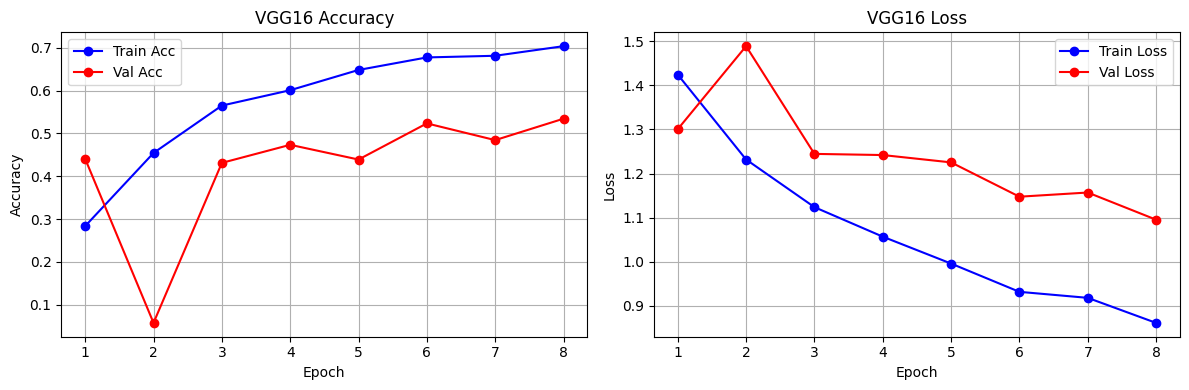


--- Training EfficientNetB0 (Fast) ---
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
📐 EfficientNetB0 Model Summary (Head Added):
   Input shape: (None, 224, 224, 3)
   Output shape: (None, 4)
   Trainable params: 5124

🚀 Training EfficientNetB0 for up to 8 epochs (Early Stopping Enabled)...
Epoch 1/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.2786 - loss: 1.4226
Epoch 1: val_accuracy improved from -inf to 0.05313, saving model to /content/drive/MyDrive/tuxpaint/effnet_best.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 59s 725ms/step - accuracy: 0.2785 - loss: 1.4225 - val_accuracy: 0.0531 - val_loss: 1.4796
Epoch 2/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 502ms/step - accuracy: 0.2692 - loss: 1.4339
Epoch 2: val_accuracy improved from 0.05313 to 0.36875, saving model to /content/drive/MyDrive/tuxpaint/effnet_best.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 38s 775ms/step - accuracy: 0.2690 - loss: 1.4337 - val_accuracy: 0.3688 - val_loss: 1.3804
Epoch 3/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.2648 - loss: 1.4134
Epoch 3: val_accuracy did not improve from 0.36875
50/50 ━━━━━━━━━━━━━━━━━━━━ 39s 792ms/step - accuracy: 0.2647 - loss: 1.4133 - val_accuracy: 0.0000e+00 - val_loss: 1.5467
Epoch 4/8
29/50 ━━━━━━━━━━━━━━━━━━━━ 14s 692ms/step - accuracy: 0.2377 - loss: 1.4257
Epoch 4: val_accuracy improved from 0.36875 to 0.46875, saving model to /content/drive/MyDrive/tuxpaint/effnet_best.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 489ms/step - accuracy: 0.2355 - loss: 1.4229 - val_accuracy: 0.4688 - val_loss: 1.3775
Epoch 5/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.2669 - loss: 1.4135
Epoch 5: val_accuracy did not improve from 0.46875
50/50 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.2667 - loss: 1.4135 - val_accuracy: 0.0531 - val_loss: 1.5633
Epoch 6/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - accuracy: 0.2567 - loss: 1.4178
Epoch 6: val_accuracy did not improve from 0.46875
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 835ms/step - accuracy: 0.2567 - loss: 1.4178 - val_accuracy: 0.0000e+00 - val_loss: 1.5369
Epoch 7/8
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.2676 - loss: 1.4127
Epoch 7: val_accuracy did not improve from 0.46875
50/50 ━━━━━━━━━━━━━━━━━━━━ 27s 547ms/step - accuracy: 0.2675 - loss: 1.4128 - val_accuracy: 0.0531 - val_loss: 1.5665
Epoch 8/8
29/50 ━━━━━━━━━━━━━━━━━━━━ 9s 455ms/step - accuracy: 0.2655 - loss: 1.3999 
Epoch 8: val_accuracy did not im

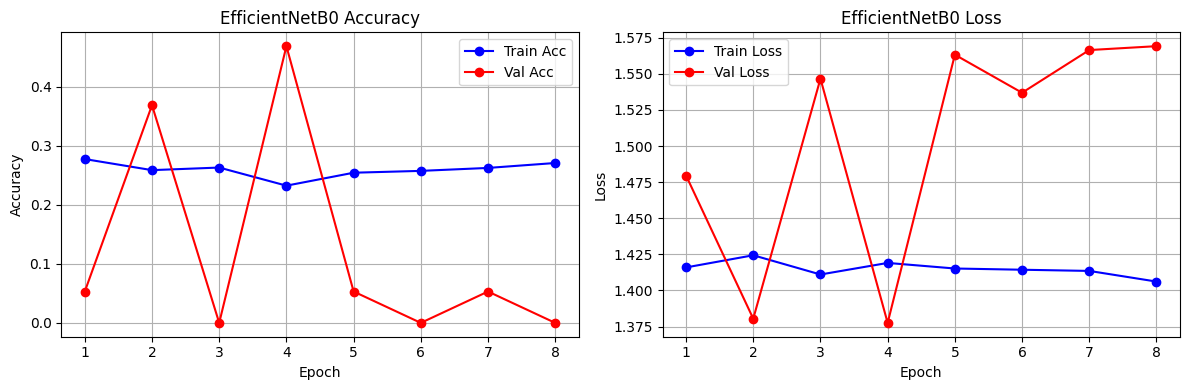

In [6]:
# ===============================
# PHASE 3.5: TRAIN VGG16 & EFFICIENTNETB0 (FAST)
# ===============================
from tensorflow.keras.applications import VGG16, EfficientNetB0
import os

# Config (Faster training for comparison)
EPOCHS_FAST = 8 # Fewer epochs for these models in this example
STEPS_FAST = 50 # Limit steps per epoch for faster run
VAL_STEPS_FAST = 20 # Limit validation steps
IMAGE_SIZE = 224
NUM_CLASSES = len(train_gen.class_indices) if 'train_gen' in globals() else 4
BASE_MODEL_OUTPUT_DIR = PROJECT_FOLDER

if 'train_gen' in globals() and 'val_gen' in globals():
    # === Train VGG16 ===
    print("\n--- Training VGG16 (Fast) ---")
    vgg_base = VGG16(include_top=False, weights='imagenet', input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    vgg_model = build_transfer_model(vgg_base, "VGG16", NUM_CLASSES)
    vgg_save_path = os.path.join(BASE_MODEL_OUTPUT_DIR, "vgg16_best.h5")
    vgg_history = train_model(vgg_model, train_gen, val_gen, vgg_save_path, "VGG16", EPOCHS_FAST, STEPS_FAST, VAL_STEPS_FAST)
    plot_history(vgg_history, "VGG16")

    # === Train EfficientNetB0 ===
    print("\n--- Training EfficientNetB0 (Fast) ---")
    effnet_base = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    effnet_model = build_transfer_model(effnet_base, "EfficientNetB0", NUM_CLASSES)
    effnet_save_path = os.path.join(BASE_MODEL_OUTPUT_DIR, "effnet_best.h5")
    effnet_history = train_model(effnet_model, train_gen, val_gen, effnet_save_path, "EfficientNetB0", EPOCHS_FAST, STEPS_FAST, VAL_STEPS_FAST)
    plot_history(effnet_history, "EfficientNetB0")
else:
    print("❌ Cannot train VGG16/EfficientNetB0: Data generators ('train_gen', 'val_gen') not found.")


--- Training InceptionV3 ---
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
📐 InceptionV3 Model Summary (Head Added):
   Input shape: (None, 224, 224, 3)
   Output shape: (None, 4)
   Trainable params: 8196

🚀 Training InceptionV3 for up to 10 epochs (Early Stopping Enabled)...
Epoch 1/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step - accuracy: 0.5963 - loss: 1.0126
Epoch 1: val_accuracy improved from -inf to 0.79252, saving model to /content/drive/MyDrive/tuxpaint/inceptionv3_best.h5


179/179 ━━━━━━━━━━━━━━━━━━━━ 137s 670ms/step - accuracy: 0.5968 - loss: 1.0114 - val_accuracy: 0.7925 - val_loss: 0.5267
Epoch 2/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - accuracy: 0.7830 - loss: 0.5728
Epoch 2: val_accuracy improved from 0.79252 to 0.80625, saving model to /content/drive/MyDrive/tuxpaint/inceptionv3_best.h5


179/179 ━━━━━━━━━━━━━━━━━━━━ 114s 563ms/step - accuracy: 0.7830 - loss: 0.5727 - val_accuracy: 0.8063 - val_loss: 0.4832
Epoch 3/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 502ms/step - accuracy: 0.8050 - loss: 0.5130
Epoch 3: val_accuracy improved from 0.80625 to 0.81541, saving model to /content/drive/MyDrive/tuxpaint/inceptionv3_best.h5


179/179 ━━━━━━━━━━━━━━━━━━━━ 139s 547ms/step - accuracy: 0.8050 - loss: 0.5130 - val_accuracy: 0.8154 - val_loss: 0.4770
Epoch 4/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.8335 - loss: 0.4540
Epoch 4: val_accuracy improved from 0.81541 to 0.81770, saving model to /content/drive/MyDrive/tuxpaint/inceptionv3_best.h5


179/179 ━━━━━━━━━━━━━━━━━━━━ 99s 555ms/step - accuracy: 0.8335 - loss: 0.4541 - val_accuracy: 0.8177 - val_loss: 0.4705
Epoch 5/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - accuracy: 0.8428 - loss: 0.4334
Epoch 5: val_accuracy improved from 0.81770 to 0.82227, saving model to /content/drive/MyDrive/tuxpaint/inceptionv3_best.h5


179/179 ━━━━━━━━━━━━━━━━━━━━ 143s 561ms/step - accuracy: 0.8428 - loss: 0.4335 - val_accuracy: 0.8223 - val_loss: 0.4464
Epoch 6/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.8316 - loss: 0.4272
Epoch 6: val_accuracy improved from 0.82227 to 0.82914, saving model to /content/drive/MyDrive/tuxpaint/inceptionv3_best.h5


179/179 ━━━━━━━━━━━━━━━━━━━━ 146s 585ms/step - accuracy: 0.8316 - loss: 0.4273 - val_accuracy: 0.8291 - val_loss: 0.4315
Epoch 7/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.8364 - loss: 0.4437
Epoch 7: val_accuracy did not improve from 0.82914
179/179 ━━━━━━━━━━━━━━━━━━━━ 98s 543ms/step - accuracy: 0.8364 - loss: 0.4437 - val_accuracy: 0.8047 - val_loss: 0.4883
Epoch 8/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - accuracy: 0.8176 - loss: 0.4763
Epoch 8: val_accuracy improved from 0.82914 to 0.84363, saving model to /content/drive/MyDrive/tuxpaint/inceptionv3_best.h5


179/179 ━━━━━━━━━━━━━━━━━━━━ 148s 582ms/step - accuracy: 0.8177 - loss: 0.4762 - val_accuracy: 0.8436 - val_loss: 0.4127
Epoch 9/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 514ms/step - accuracy: 0.8459 - loss: 0.4175
Epoch 9: val_accuracy did not improve from 0.84363
179/179 ━━━━━━━━━━━━━━━━━━━━ 97s 544ms/step - accuracy: 0.8459 - loss: 0.4176 - val_accuracy: 0.8284 - val_loss: 0.4453
Epoch 10/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - accuracy: 0.8337 - loss: 0.4619
Epoch 10: val_accuracy improved from 0.84363 to 0.85202, saving model to /content/drive/MyDrive/tuxpaint/inceptionv3_best.h5


179/179 ━━━━━━━━━━━━━━━━━━━━ 144s 555ms/step - accuracy: 0.8338 - loss: 0.4618 - val_accuracy: 0.8520 - val_loss: 0.3745
Restoring model weights from the end of the best epoch: 10.
✅ Training InceptionV3 complete.


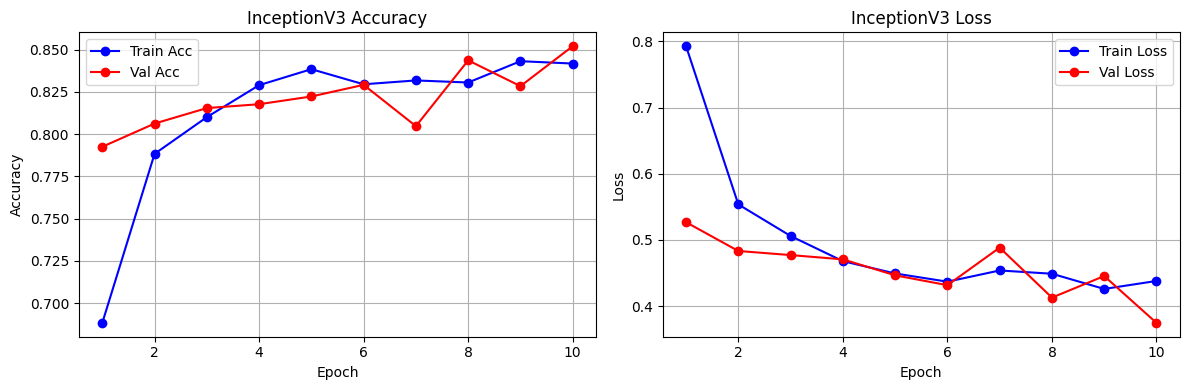


--- Training DenseNet121 ---
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
📐 DenseNet121 Model Summary (Head Added):
   Input shape: (None, 224, 224, 3)
   Output shape: (None, 4)
   Trainable params: 4100

🚀 Training DenseNet121 for up to 10 epochs (Early Stopping Enabled)...
Epoch 1/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 577ms/step - accuracy: 0.4785 - loss: 1.3367
Epoch 1: val_accuracy improved from -inf to 0.75973, saving model to /content/drive/MyDrive/tuxpaint/densenet121_best.h5


179/179 ━━━━━━━━━━━━━━━━━━━━ 162s 746ms/step - accuracy: 0.4792 - loss: 1.3349 - val_accuracy: 0.7597 - val_loss: 0.6158
Epoch 2/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 502ms/step - accuracy: 0.7534 - loss: 0.6442
Epoch 2: val_accuracy improved from 0.75973 to 0.80092, saving model to /content/drive/MyDrive/tuxpaint/densenet121_best.h5


179/179 ━━━━━━━━━━━━━━━━━━━━ 104s 581ms/step - accuracy: 0.7535 - loss: 0.6440 - val_accuracy: 0.8009 - val_loss: 0.5019
Epoch 3/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - accuracy: 0.7910 - loss: 0.5552
Epoch 3: val_accuracy improved from 0.80092 to 0.80625, saving model to /content/drive/MyDrive/tuxpaint/densenet121_best.h5


179/179 ━━━━━━━━━━━━━━━━━━━━ 98s 546ms/step - accuracy: 0.7911 - loss: 0.5551 - val_accuracy: 0.8063 - val_loss: 0.5083
Epoch 4/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.8237 - loss: 0.4911
Epoch 4: val_accuracy improved from 0.80625 to 0.82838, saving model to /content/drive/MyDrive/tuxpaint/densenet121_best.h5


179/179 ━━━━━━━━━━━━━━━━━━━━ 143s 549ms/step - accuracy: 0.8237 - loss: 0.4911 - val_accuracy: 0.8284 - val_loss: 0.4558
Epoch 5/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.8177 - loss: 0.4860
Epoch 5: val_accuracy did not improve from 0.82838
179/179 ━━━━━━━━━━━━━━━━━━━━ 142s 547ms/step - accuracy: 0.8177 - loss: 0.4860 - val_accuracy: 0.8177 - val_loss: 0.4649
Epoch 6/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 518ms/step - accuracy: 0.8281 - loss: 0.4705
Epoch 6: val_accuracy did not improve from 0.82838
179/179 ━━━━━━━━━━━━━━━━━━━━ 142s 549ms/step - accuracy: 0.8281 - loss: 0.4705 - val_accuracy: 0.8177 - val_loss: 0.4785
Epoch 7/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 519ms/step - accuracy: 0.8320 - loss: 0.4749
Epoch 7: val_accuracy did not improve from 0.82838
179/179 ━━━━━━━━━━━━━━━━━━━━ 142s 549ms/step - accuracy: 0.8319 - loss: 0.4749 - val_accuracy: 0.8192 - val_loss: 0.4597
Epoch 8/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - accuracy: 0.8246 - loss: 0.4563
Epoch 8: va

179/179 ━━━━━━━━━━━━━━━━━━━━ 106s 595ms/step - accuracy: 0.8311 - loss: 0.4652 - val_accuracy: 0.8322 - val_loss: 0.4323
Epoch 10/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 515ms/step - accuracy: 0.8351 - loss: 0.4393
Epoch 10: val_accuracy did not improve from 0.83219
179/179 ━━━━━━━━━━━━━━━━━━━━ 133s 545ms/step - accuracy: 0.8351 - loss: 0.4394 - val_accuracy: 0.8276 - val_loss: 0.4274
Restoring model weights from the end of the best epoch: 10.
✅ Training DenseNet121 complete.


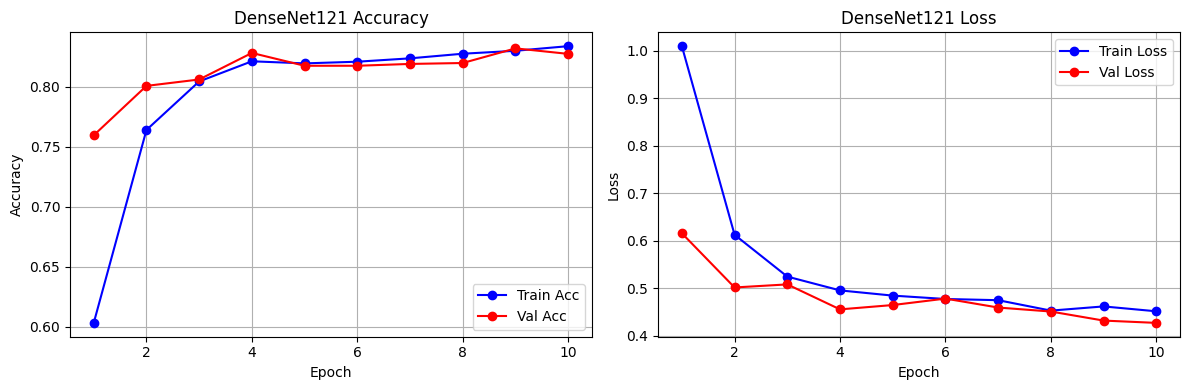


✅ Additional model training phase complete.


In [7]:
# ===============================
# PHASE 3.6 (Modified): ADDITIONAL MODEL TRAINING (INCEPTIONV3 & DENSENET121)
# ===============================
from tensorflow.keras.applications import InceptionV3, DenseNet121 # Import new models
# Other imports like Model, Dense, Dropout, ModelCheckpoint, plt, os are likely already done
# Ensure utility functions (build_transfer_model, train_model, plot_history) are defined from Phase 3.1-3.3

# Config
EPOCHS_NEW = 10 # Slightly more epochs for these models
# Use full steps if possible for better comparison, adjust if needed for time
STEPS_NEW = len(train_gen) if 'train_gen' in globals() else 50
VAL_STEPS_NEW = len(val_gen) if 'val_gen' in globals() else 20
IMAGE_SIZE = 224 # Keep consistent image size (Note: InceptionV3 prefers 299x299)
NUM_CLASSES = len(train_gen.class_indices) if 'train_gen' in globals() else 4
BASE_MODEL_OUTPUT_DIR = PROJECT_FOLDER # Use main project folder

if 'train_gen' in globals() and 'val_gen' in globals():

    # === Train InceptionV3 ===
    print("\n--- Training InceptionV3 ---")
    # Note: InceptionV3 typically expects 299x299 input, but can work with 224x224.
    # Results might be suboptimal compared to using its native size.
    inc_base = InceptionV3(include_top=False, weights='imagenet', input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    inc_model = build_transfer_model(inc_base, "InceptionV3", NUM_CLASSES)
    inc_save_path = os.path.join(BASE_MODEL_OUTPUT_DIR, "inceptionv3_best.h5")
    inc_history = train_model(inc_model, train_gen, val_gen, inc_save_path, "InceptionV3", EPOCHS_NEW, STEPS_NEW, VAL_STEPS_NEW)
    plot_history(inc_history, "InceptionV3")


    # === Train DenseNet121 ===
    print("\n--- Training DenseNet121 ---")
    dense_base = DenseNet121(include_top=False, weights='imagenet', input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    dense_model = build_transfer_model(dense_base, "DenseNet121", NUM_CLASSES)
    dense_save_path = os.path.join(BASE_MODEL_OUTPUT_DIR, "densenet121_best.h5")
    dense_history = train_model(dense_model, train_gen, val_gen, dense_save_path, "DenseNet121", EPOCHS_NEW, STEPS_NEW, VAL_STEPS_NEW)
    plot_history(dense_history, "DenseNet121")

    print("\n✅ Additional model training phase complete.")
else:
    print("❌ Cannot train InceptionV3/DenseNet121: Data generators ('train_gen', 'val_gen') not found.")

## Phase 3.7: Model Comparison and Best Model Selection


🔍 Evaluating ResNet50 from /content/drive/MyDrive/tuxpaint/resnet50_best.h5...


41/41 ━━━━━━━━━━━━━━━━━━━━ 13s 240ms/step

📊 Classification Report for ResNet50:
              precision    recall  f1-score   support

      glioma       0.66      0.34      0.45       300
  meningioma       0.50      0.36      0.42       306
     notumor       0.64      0.82      0.72       405
   pituitary       0.56      0.76      0.65       300

    accuracy                           0.59      1311
   macro avg       0.59      0.57      0.56      1311
weighted avg       0.59      0.59      0.57      1311


🔍 Evaluating VGG16 from /content/drive/MyDrive/tuxpaint/vgg16_best.h5...


41/41 ━━━━━━━━━━━━━━━━━━━━ 18s 421ms/step

📊 Classification Report for VGG16:
              precision    recall  f1-score   support

      glioma       0.74      0.69      0.71       300
  meningioma       0.60      0.37      0.46       306
     notumor       0.81      0.90      0.85       405
   pituitary       0.68      0.88      0.77       300

    accuracy                           0.72      1311
   macro avg       0.71      0.71      0.70      1311
weighted avg       0.71      0.72      0.71      1311


🔍 Evaluating EfficientNetB0 from /content/drive/MyDrive/tuxpaint/effnet_best.h5...


41/41 ━━━━━━━━━━━━━━━━━━━━ 19s 335ms/step

📊 Classification Report for EfficientNetB0:
              precision    recall  f1-score   support

      glioma       0.25      1.00      0.40       300
  meningioma       0.00      0.00      0.00       306
     notumor       0.87      0.20      0.33       405
   pituitary       0.00      0.00      0.00       300

    accuracy                           0.29      1311
   macro avg       0.28      0.30      0.18      1311
weighted avg       0.33      0.29      0.19      1311


🔍 Evaluating InceptionV3 from /content/drive/MyDrive/tuxpaint/inceptionv3_best.h5...


41/41 ━━━━━━━━━━━━━━━━━━━━ 16s 270ms/step

📊 Classification Report for InceptionV3:
              precision    recall  f1-score   support

      glioma       0.90      0.80      0.85       300
  meningioma       0.72      0.68      0.70       306
     notumor       0.90      0.96      0.93       405
   pituitary       0.87      0.94      0.90       300

    accuracy                           0.85      1311
   macro avg       0.85      0.84      0.84      1311
weighted avg       0.85      0.85      0.85      1311


🔍 Evaluating DenseNet121 from /content/drive/MyDrive/tuxpaint/densenet121_best.h5...


41/41 ━━━━━━━━━━━━━━━━━━━━ 26s 402ms/step

📊 Classification Report for DenseNet121:
              precision    recall  f1-score   support

      glioma       0.83      0.83      0.83       300
  meningioma       0.77      0.56      0.65       306
     notumor       0.91      0.93      0.92       405
   pituitary       0.79      0.98      0.87       300

    accuracy                           0.83      1311
   macro avg       0.82      0.82      0.82      1311
weighted avg       0.83      0.83      0.82      1311


📊 Model Comparison (Metrics Table):
                Accuracy  Weighted Precision  Weighted Recall  Weighted F1-Score
ResNet50          0.5919              0.5919           0.5919             0.5705
VGG16             0.7239              0.7132           0.7239             0.7081
EfficientNetB0    0.2906              0.3254           0.2906             0.1909
InceptionV3       0.8520              0.8502           0.8520             0.8499
DenseNet121       0.8322              0

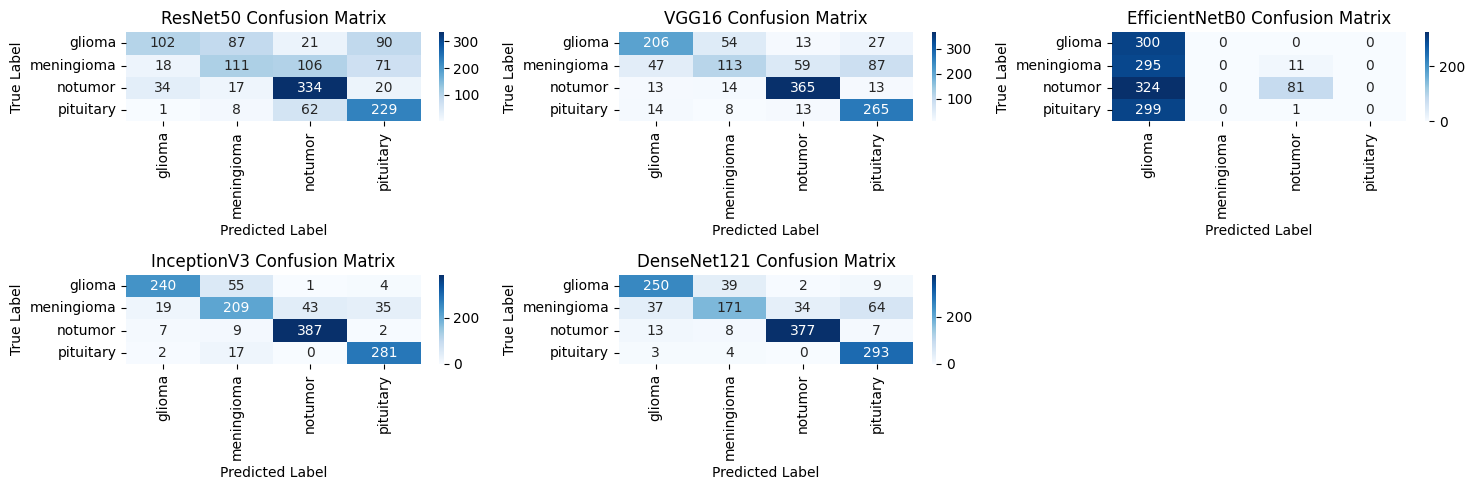


🚀 The best model based on Weighted F1-Score is: InceptionV3 with F1-score: 0.8499


✅ Best model (InceptionV3) saved for chatbot: /content/drive/MyDrive/tuxpaint/best_model_for_chatbot.h5


In [8]:
# ===============================
# PHASE 3.7 (Modified): FULL MODEL COMPARISON AND BEST SELECTION
# ===============================
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd
import tensorflow as tf
import os # Import os for path joining
import seaborn as sns # For plotting confusion matrix
import matplotlib.pyplot as plt

# Config
BASE_MODEL_OUTPUT_DIR = PROJECT_FOLDER # Use main project folder
IMAGE_SIZE = 224
# Define class names - **Ensure this order matches train_gen.class_indices**
# Check the output of cell 2 if unsure, common order is alphabetical
# Assuming alphabetical order based on common ImageDataGenerator behavior:
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary'] # Example: Check your actual order!
NUM_CLASSES = len(CLASS_NAMES)

# Function to evaluate models (Compile within function for loaded models)
def evaluate_model(model_path, val_gen, model_name):
    print(f"\n🔍 Evaluating {model_name} from {model_path}...")
    if not os.path.exists(model_path):
        print(f"❌ Error: Model file not found at {model_path}")
        return None, None, None # Return None for report, confusion matrix, and accuracy

    model = tf.keras.models.load_model(model_path)
    # Compile model before evaluation (good practice for loaded H5)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Reset generator and predict
    val_gen.reset()
    try:
        # Predict on validation data
        # Using predict() is generally preferred over evaluate() for getting metrics like classification report
        # Ensure sufficient steps to cover the validation set if using limited steps elsewhere
        val_steps_eval = len(val_gen)
        y_pred_probs = model.predict(val_gen, steps=val_steps_eval, verbose=1)

        # Check if predictions are valid
        if y_pred_probs is None or y_pred_probs.shape[0] != val_gen.n:
             print(f"⚠️ Prediction output size mismatch or None for {model_name}. Expected {val_gen.n}, Got {y_pred_probs.shape[0] if y_pred_probs is not None else 'None'}")
             # Attempt evaluation as fallback
             val_gen.reset()
             loss, accuracy = model.evaluate(val_gen, steps=val_steps_eval, verbose=1)
             print(f"{model_name} Fallback Evaluation - Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")
             # Cannot generate report/confusion matrix reliably here
             return None, None, accuracy


        y_pred_classes = np.argmax(y_pred_probs, axis=1)
        y_true = val_gen.classes # Make sure val_gen shuffle=False

        # Ensure labels match prediction length (important if val_gen steps were limited during predict)
        num_predicted_samples = len(y_pred_classes)
        if len(y_true) != num_predicted_samples:
            print(f"⚠️ Warning: True labels ({len(y_true)}) and predicted labels ({num_predicted_samples}) lengths mismatch for {model_name}. Using labels matching predictions.")
            # This might happen if val_gen has more samples than were predicted (if steps < len(val_gen))
            # We should use the classes corresponding to the samples predicted
            y_true = y_true[:num_predicted_samples]


        # Get classification report and confusion matrix
        print(f"\n📊 Classification Report for {model_name}:")
        class_report = classification_report(y_true, y_pred_classes, target_names=CLASS_NAMES, output_dict=True, zero_division=0)
        print(classification_report(y_true, y_pred_classes, target_names=CLASS_NAMES, zero_division=0))

        confusion = confusion_matrix(y_true, y_pred_classes)

        # Extract overall accuracy from the report
        overall_accuracy = class_report['accuracy']

        return class_report, confusion, overall_accuracy

    except Exception as e:
        print(f"❌ Error evaluating model {model_name}: {e}")
        # Attempt evaluation as fallback
        try:
            val_gen.reset()
            val_steps_eval = len(val_gen)
            loss, accuracy = model.evaluate(val_gen, steps=val_steps_eval, verbose=1)
            print(f"{model_name} Fallback Evaluation on Error - Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")
            return None, None, accuracy
        except Exception as eval_e:
            print(f"❌ Error during fallback evaluation for {model_name}: {eval_e}")
            return None, None, None


# --- Model Paths --- Check these paths exist!
model_paths = {
    "ResNet50": os.path.join(BASE_MODEL_OUTPUT_DIR, "resnet50_best.h5"),
    "VGG16": os.path.join(BASE_MODEL_OUTPUT_DIR, "vgg16_best.h5"),
    "EfficientNetB0": os.path.join(BASE_MODEL_OUTPUT_DIR, "effnet_best.h5"),
    "InceptionV3": os.path.join(BASE_MODEL_OUTPUT_DIR, "inceptionv3_best.h5"),
    "DenseNet121": os.path.join(BASE_MODEL_OUTPUT_DIR, "densenet121_best.h5"),
}

# --- Evaluate All Models --- Print missing files
results = {}
accuracies = {}
confusion_matrices = {}
missing_models = []

# Assuming val_gen is defined and available from Phase 2
if 'val_gen' not in globals():
    print("❌ Error: 'val_gen' (validation generator) not found. Please run Phase 2 first.")
else:
    for name, path in model_paths.items():
        if not os.path.exists(path):
            print(f"⚠️ Model file missing for {name} at {path}. Skipping evaluation.")
            missing_models.append(name)
            continue # Skip to next model if file doesn't exist

        report, confusion, accuracy = evaluate_model(path, val_gen, name)
        if report and confusion is not None and accuracy is not None:
            results[name] = report
            confusion_matrices[name] = confusion
            accuracies[name] = accuracy # Store accuracy from report if available
        elif accuracy is not None: # Store accuracy from fallback evaluate() if report failed
             accuracies[name] = accuracy
             results[name] = None # Mark report as unavailable
             confusion_matrices[name] = None
        else:
            print(f"⚠️ Could not evaluate {name}.")
            accuracies[name] = 0.0 # Assign 0 accuracy if evaluation failed completely
            results[name] = None
            confusion_matrices[name] = None


# --- Compile Comparison Metrics --- Filter out models that weren't evaluated
comparison_data = []
models_evaluated = [name for name in model_paths if name not in missing_models and name in accuracies]

for model_name in models_evaluated:
    report = results.get(model_name)
    accuracy = accuracies.get(model_name)

    if report: # Extract detailed metrics if report exists
         precision = report['weighted avg']['precision']
         recall = report['weighted avg']['recall']
         f1_score = report['weighted avg']['f1-score']
         comparison_data.append([accuracy, precision, recall, f1_score])
    elif accuracy is not None: # If only accuracy exists (from evaluate fallback)
         # Assign NaN or 0 for unavailable metrics
         comparison_data.append([accuracy, np.nan, np.nan, np.nan])
         print(f"⚠️ Using only accuracy for {model_name} in comparison table.")
    # No 'else' needed as we filter models_evaluated based on presence in accuracies


# Create comparison DataFrame
metrics = ['Accuracy', 'Weighted Precision', 'Weighted Recall', 'Weighted F1-Score']
if comparison_data: # Only create DataFrame if there is data
    comparison_df = pd.DataFrame(comparison_data, columns=metrics, index=models_evaluated)

    # Display the results
    print("\n📊 Model Comparison (Metrics Table):")
    # Format floats for better readability
    print(comparison_df.to_string(float_format="%.4f", na_rep="N/A"))
else:
    print("\n📊 No models were successfully evaluated to generate a comparison table.")
    comparison_df = pd.DataFrame() # Create empty df

# --- Plot Confusion Matrices --- Check if dict is not empty
if confusion_matrices:
    print("\n📊 Confusion Matrices:")
    num_models_with_cm = len([m for m in confusion_matrices.values() if m is not None])
    if num_models_with_cm > 0:
        plt.figure(figsize=(min(15, 5 * num_models_with_cm), 5))
        # Dynamically adjust grid size
        cols_cm = min(3, num_models_with_cm) # Max 3 columns
        rows_cm = (num_models_with_cm + cols_cm - 1) // cols_cm

        plot_index = 1
        for name, matrix in confusion_matrices.items():
            if matrix is not None:
                plt.subplot(rows_cm, cols_cm, plot_index)
                sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
                plt.title(f"{name} Confusion Matrix")
                plt.xlabel("Predicted Label")
                plt.ylabel("True Label")
                plot_index += 1

        plt.tight_layout()
        plt.show()
    else:
        print("\nNo confusion matrices generated successfully.")
else:
    print("\nNo confusion matrices available.")


# --- Select and Save the Best Model --- Check DataFrame has F1 score
if not comparison_df.empty and 'Weighted F1-Score' in comparison_df.columns:
     # Handle potential NaN values if some models failed evaluation for F1
     comparison_df_cleaned = comparison_df.dropna(subset=['Weighted F1-Score'])
     if not comparison_df_cleaned.empty:
         best_model_name = comparison_df_cleaned['Weighted F1-Score'].idxmax()
         best_model_f1 = comparison_df_cleaned.loc[best_model_name, 'Weighted F1-Score']
         print(f"\n🚀 The best model based on Weighted F1-Score is: {best_model_name} with F1-score: {best_model_f1:.4f}")

         # Save the best model file
         best_model_path_source = model_paths[best_model_name]
         best_model_path_dest = os.path.join(BASE_MODEL_OUTPUT_DIR, "best_model_for_chatbot.h5")

         if os.path.exists(best_model_path_source):
             try:
                 # Load and save to ensure it's saveable
                 best_model = tf.keras.models.load_model(best_model_path_source)
                 best_model.save(best_model_path_dest)
                 print(f"✅ Best model ({best_model_name}) saved for chatbot: {best_model_path_dest}")
             except Exception as e:
                 print(f"❌ Error saving the best model {best_model_name}: {e}")
         else:
             print(f"❌ Error: Source model file not found for the best model {best_model_name} at {best_model_path_source}")
     else:
         print("⚠️ Could not determine the best model based on F1-score (possibly due to evaluation failures or NaNs). Please check the comparison table.")

else:
    print("⚠️ Comparison DataFrame is empty or F1-Score column missing. Cannot select best model.")

## Phase 4: Visualization Techniques (Grad-CAM Setup)

In [9]:
# ===============================
# PHASE 4: GRAD-CAM VISUALIZATION SETUP
# ===============================
# The actual Grad-CAM implementation and usage are integrated into the Gradio app (Phase 5)
# This cell can be used for standalone testing of Grad-CAM if needed.

import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

print("ℹ️ Grad-CAM functions are defined within Phase 5 (Gradio App).")
print("   You can run Phase 5 to see Grad-CAM in action.")

# Example: You could load the best model here and test Grad-CAM on a sample image
# (Requires functions from Phase 5 to be defined or copied here for standalone run)
'''
BEST_MODEL_PATH = os.path.join(PROJECT_FOLDER, "best_model_for_chatbot.h5")
if os.path.exists(BEST_MODEL_PATH):
    test_model = tf.keras.models.load_model(BEST_MODEL_PATH)
    test_model.compile() # Compile after loading
    print("Test model loaded for Grad-CAM testing.")

    # Find a sample image path (e.g., from preprocessed test set)
    SAMPLE_IMAGE_PATH = os.path.join(OUTPUT_TEST_PREPROCESSED_PATH, 'glioma', 'Te-gl_0014.jpg') # Example
    if os.path.exists(SAMPLE_IMAGE_PATH):
        # Need preprocess_image, find_last_conv_layer, generate_gradcam, overlay_gradcam functions here
        # img = cv2.imread(SAMPLE_IMAGE_PATH)
        # processed_img_array = preprocess_image(img) # Assuming preprocess_image is defined
        # layer_name = find_last_conv_layer(test_model) # Assuming defined
        # heatmap = generate_gradcam(test_model, processed_img_array, layer_name) # Assuming defined
        # superimposed = overlay_gradcam(heatmap, img) # Assuming defined

        # plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
        # plt.title("Example Grad-CAM Overlay")
        # plt.axis('off')
        # plt.show()
        pass # Placeholder for actual test code
    else:
        print(f"Sample image not found: {SAMPLE_IMAGE_PATH}")
else:
    print("Best model not found, cannot test Grad-CAM.")
'''

ℹ️ Grad-CAM functions are defined within Phase 5 (Gradio App).
   You can run Phase 5 to see Grad-CAM in action.


'\nBEST_MODEL_PATH = os.path.join(PROJECT_FOLDER, "best_model_for_chatbot.h5")\nif os.path.exists(BEST_MODEL_PATH):\n    test_model = tf.keras.models.load_model(BEST_MODEL_PATH)\n    test_model.compile() # Compile after loading\n    print("Test model loaded for Grad-CAM testing.")\n\n    # Find a sample image path (e.g., from preprocessed test set)\n    SAMPLE_IMAGE_PATH = os.path.join(OUTPUT_TEST_PREPROCESSED_PATH, \'glioma\', \'Te-gl_0014.jpg\') # Example\n    if os.path.exists(SAMPLE_IMAGE_PATH):\n        # Need preprocess_image, find_last_conv_layer, generate_gradcam, overlay_gradcam functions here\n        # img = cv2.imread(SAMPLE_IMAGE_PATH)\n        # processed_img_array = preprocess_image(img) # Assuming preprocess_image is defined\n        # layer_name = find_last_conv_layer(test_model) # Assuming defined\n        # heatmap = generate_gradcam(test_model, processed_img_array, layer_name) # Assuming defined\n        # superimposed = overlay_gradcam(heatmap, img) # Assuming defi

## Phase 5: Gradio Chatbot Interface

In [22]:
# ===============================
# PHASE 5 (Modified): GRADIO CHATBOT INTERFACE
# ===============================

# Ensure Gradio is installed
try:
    import gradio as gr
except ImportError:
    print("Installing Gradio...")
    import os
    os.system("pip install gradio -q")
    import gradio as gr

import tensorflow as tf
import cv2
import numpy as np
import os
import traceback

print(f"TensorFlow Version: {tf.__version__}")
print(f"Gradio Version: {gr.__version__}")
print(f"OpenCV Version: {cv2.__version__}")

# Define IMAGE_SIZE & Paths
IMAGE_SIZE = 224
PROJECT_FOLDER = PROJECT_FOLDER = os.path.join(BASE_DRIVE_PATH, 'tuxpaint')  # Replace with your actual path
BASE_MODEL_OUTPUT_DIR = PROJECT_FOLDER

# --- Load the Best Model ---
best_model_path = os.path.join(BASE_MODEL_OUTPUT_DIR, "best_model_for_chatbot.h5")
best_model = None

if not os.path.exists(best_model_path):
    print(f"❌ CRITICAL ERROR: Best model not found at {best_model_path}.")
else:
    print(f"🧠 Loading best model from: {best_model_path}")
    try:
        best_model = tf.keras.models.load_model(best_model_path)
        best_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        print("✅ Best model loaded and compiled successfully.")
        best_model.summary(line_length=100)
    except Exception as e:
        print(f"❌ CRITICAL ERROR: Failed to load or compile the best model: {e}")
        best_model = None

CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
NO_TUMOR_CLASS_NAME = "notumor"

if len(CLASS_NAMES) != (best_model.output_shape[-1] if best_model else 0):
    print(f"⚠️ WARNING: CLASS_NAMES length mismatch.")

# --- Helper Functions ---
def find_last_conv_layer(model):
    if model is None: return None
    for layer in reversed(model.layers):
        if isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.DepthwiseConv2D, tf.keras.layers.SeparableConv2D)):
            if not any(keyword in layer.name.lower() for keyword in ['pred', 'fc', 'classifier', 'dense', 'head']):
                print(f"✅ Grad-CAM layer: {layer.name}")
                return layer.name
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Activation) and layer.activation.__name__ == 'relu':
            idx = model.layers.index(layer) - 1
            if idx >= 0 and isinstance(model.layers[idx], (tf.keras.layers.Conv2D, tf.keras.layers.BatchNormalization, tf.keras.layers.MaxPooling2D)):
                print(f"✅ Using ReLU Activation layer: {layer.name}")
                return layer.name
    for lname in ['conv5_block3_out', 'block5_conv3', 'top_conv', 'mixed10', 'relu']:
        try:
            if model.get_layer(lname): return lname
        except ValueError: continue
    print("❌ No suitable Grad-CAM layer found.")
    return None

def generate_gradcam(model, img_array, layer_name):
    if model is None or layer_name is None:
        return None
    try:
        grad_model = tf.keras.models.Model([model.inputs], [model.get_layer(layer_name).output, model.output])
    except ValueError as e:
        print(f"❌ Grad-CAM layer error: {e}")
        return None

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        class_output = predictions[:, class_idx]
    grads = tape.gradient(class_output, conv_outputs)
    if grads is None:
        return None
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = np.maximum(heatmap, 0)
    max_val = np.max(heatmap)
    if max_val != 0:
        heatmap /= max_val
    return heatmap

def preprocess_image_gradio(image):
    try:
        if image is None: return None
        if image.shape[-1] != 3:
            image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        image_resized = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
        image_normalized = image_resized.astype(np.float32) / 255.0
        return np.expand_dims(image_normalized, axis=0)
    except Exception as e:
        print(f"❌ Preprocessing error: {e}")
        return None

def overlay_gradcam_gradio(heatmap, original_image, alpha=0.5):
    if heatmap is None:
        return original_image
    try:
        if original_image.dtype != np.uint8:
            img_uint8_rgb = (original_image * 255).astype(np.uint8)
        else:
            img_uint8_rgb = original_image
        heatmap_resized = cv2.resize(heatmap, (img_uint8_rgb.shape[1], img_uint8_rgb.shape[0]))
        heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
        img_uint8_bgr = cv2.cvtColor(img_uint8_rgb, cv2.COLOR_RGB2BGR)
        superimposed = cv2.addWeighted(img_uint8_bgr, 1 - alpha, heatmap_color, alpha, 0)
        return cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB)
    except Exception as e:
        print(f"❌ Overlay error: {e}")
        return original_image

def draw_bounding_box_viz(image, mask):
    if mask is None:
        return image
    try:
        mask = (mask * 255).astype(np.uint8) if mask.dtype != np.uint8 else mask
        if len(mask.shape) == 3:
            mask = mask[:, :, 0]
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for contour in contours:
            if cv2.contourArea(contour) > 500:
                x, y, w, h = cv2.boundingRect(contour)
                cv2.rectangle(image, (x, y), (x+w, y+h), (0, 255, 0), 2)
    except Exception as e:
        print(f"❌ Bounding box error: {e}")
    return image

def calculate_region_properties_viz(mask):
    props = []
    try:
        mask = (mask * 255).astype(np.uint8) if mask.dtype != np.uint8 else mask
        if len(mask.shape) == 3:
            mask = mask[:, :, 0]
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for contour in contours:
            area = cv2.contourArea(contour)
            if area > 500:
                M = cv2.moments(contour)
                cX, cY = int(M["m10"] / M["m00"]), int(M["m01"] / M["m00"]) if M["m00"] != 0 else (0, 0)
                props.append({"Area": area, "Centroid": (cX, cY)})
    except Exception as e:
        print(f"❌ Region props error: {e}")
    return props

# --- Main Gradio Prediction Function ---
def predict_and_visualize(image):
    if best_model is None:
        return None, "❌ Error: Model not loaded."
    if image is None:
        return None, "❌ Error: No image provided."

    try:
        if image.dtype != np.uint8:
            original = (image * 255).astype(np.uint8) if np.max(image) <= 1.0 else image.astype(np.uint8)
        else:
            original = image.copy()

        img_array = preprocess_image_gradio(original)
        if img_array is None:
            return None, "❌ Preprocessing failed."

        pred = best_model.predict(img_array)
        class_idx = np.argmax(pred[0])
        class_name = CLASS_NAMES[class_idx]
        prob = pred[0][class_idx]
        is_tumor = class_name != NO_TUMOR_CLASS_NAME

        result = f"Prediction: {class_name}\nConfidence: {prob:.2%}\nTumor Present: {'Yes' if is_tumor else 'No'}\n---\n"

        heatmap = generate_gradcam(best_model, img_array, find_last_conv_layer(best_model))
        overlay = overlay_gradcam_gradio(heatmap, original)
        final_img = overlay
        if heatmap is not None:
            resized = cv2.resize(heatmap, (original.shape[1], original.shape[0]))
            _, binary_mask = cv2.threshold(resized, 0.4, 1.0, cv2.THRESH_BINARY)
            binary_mask = (binary_mask * 255).astype(np.uint8)
            final_img = draw_bounding_box_viz(overlay, binary_mask)
            props = calculate_region_properties_viz(binary_mask)
            if props:
                result += "Detected Region Properties:\n"
                for i, p in enumerate(props):
                    result += f"  Region {i+1}: Area={p['Area']:.0f}, Centroid={p['Centroid']}\n"
            else:
                result += "No significant regions found.\n"
        else:
            result += "Grad-CAM failed.\n"

        return final_img, result.strip()

    except Exception as e:
        traceback.print_exc()
        fallback = image.astype(np.uint8) if image.dtype != np.uint8 else image
        return fallback, f"An error occurred: {e}"

# --- Gradio UI ---
if best_model is not None:
    iface = gr.Interface(
        fn=predict_and_visualize,
        inputs=gr.Image(type="numpy", label="Upload Brain MRI Image"),
        outputs=[
            gr.Image(type="numpy", label="Processed Image with Grad-CAM"),
            gr.Textbox(label="Analysis Results")
        ],
        title="🧠 Brain Tumor Detection and Analysis (Enhanced)",
        description=(
            "Upload a brain MRI image. The model predicts tumor type and visualizes focus areas using Grad-CAM. "
            f"Classes: {', '.join(CLASS_NAMES)}"
        ),
        allow_flagging="never",
        cache_examples=False
    )
    print("\n🚀 Launching Gradio Interface...")
    iface.launch(share=True, debug=True)
else:
    print("❌ Gradio interface cannot be launched. Model not loaded.")


TensorFlow Version: 2.18.0
Gradio Version: 5.29.0
OpenCV Version: 4.11.0
🧠 Loading best model from: /content/drive/MyDrive/tuxpaint/best_model_for_chatbot.h5


✅ Best model loaded and compiled successfully.


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape            ┃        Param # ┃ Connected to            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)  │ (None, 224, 224, 3)     │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2d (Conv2D)             │ (None, 111, 111, 32)    │            864 │ input_layer_3[0][0]     │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ batch_normalization         │ (None, 111, 111, 32)    │             96 │ conv2d[0][0]            │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ activation (Activation)     │ (None, 111, 111, 32)    │              0 │ batch_normalization[0]… │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2d_1 (Conv2D)           │ (None, 109, 109, 32)    │          9,216 │ activation[0][0]        │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ batch_normalization_1       │ (None, 109, 109, 32)    │             96 │ conv2d_1[0][0]          │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ activation_1 (Activation)   │ (None, 109, 109, 32)    │              0 │ batch_normalization_1[… │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2d_2 (Conv2D)           │ (None, 109, 109, 64)    │         18,432 │ activation_1[0][0]      │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ batch_normalization_2       │ (None, 109, 109, 64)    │            192 │ conv2d_2[0][0]          │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ activation_2 (Activation)   │ (None, 109, 109, 64)    │              0 │ batch_normalization_2[… │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ max_pooling2d               │ (None, 54, 54, 64)      │              0 │ activation_2[0][0]      │
│ (MaxPooling2D)              │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2d_3 (Conv2D)           │ (None, 54, 54, 80)      │          5,120 │ max_pooling2d[0][0]     │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ batch_normalization_3       │ (None, 54, 54, 80)      │            240 │ conv2d_3[0][0]          │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ activation_3 (Activation)   │ (None, 54, 54, 80)      │              0 │ batch_normalization_3[… │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2d_4 (Conv2D)           │ (None, 52, 52, 192)     │        138,240 │ activation_3[0][0]      │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ batch_normalization_4       │ (None, 52, 52, 192)     │            576 │ conv2d_4[0][0]          │
│ (BatchNormalization)        │                         │    

 Total params: 21,810,980 (83.20 MB)

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
✅ Grad-CAM layer: conv2d_93


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_3']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
✅ Grad-CAM layer: conv2d_93


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_3']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://45ed2c144c52658c32.gradio.live


In [26]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/tuxpaint/effnet_best.h5')
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,054,697 (15.47 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 2 (12.00 B)

In [27]:
import os

# Rename the file to match the expected model path
os.rename('/content/drive/MyDrive/tuxpaint/effnet_best.h5', '/content/drive/MyDrive/tuxpaint/efficientnetb0_best_fast.h5')


In [28]:
# ===============================
# PHASE 4: GRADIO CHATBOT INTERFACE (ENHANCED CV)
# (Corrected Paths, Indentation, and Enhanced CV Output Text)
# ===============================

print("--- Phase 4: Initializing Gradio Application ---")
print("Description: This phase sets up and launches the interactive Gradio web application.")
print("It will load one of the trained models (ideally the best one from Phase 3)")
print("and provide an interface for image upload, classification, Grad-CAM visualization,")
print("and detailed CV-based region analysis with informational suggestions.")
print("-" * 70)

# Ensure Gradio is installed
try:
    import gradio as gr
except ImportError:
    print("⏳ Installing Gradio...")
    import subprocess
    import sys
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "gradio", "-q"])
        import gradio as gr
        print("✅ Gradio installed successfully.")
    except Exception as e:
        print(f"❌ Failed to install Gradio: {e}")
        gr = None # Set to None if install fails

if gr is None:
    print("‼️ Gradio could not be imported or installed. The UI cannot be launched.")
else:
    # TensorFlow, OpenCV, NumPy, OS, Traceback should be imported from Phase 0
    # If not, ensure Phase 0 ran successfully in the current session.
    import tensorflow as tf
    import cv2
    import numpy as np
    import os
    import traceback # For detailed error messages
    import random # For selecting example images

    print(f"\nUsing TensorFlow Version: {tf.__version__}")
    print(f"Using Gradio Version: {gr.__version__}")
    print(f"Using OpenCV Version: {cv2.__version__}")

    # --- Configuration based on your provided paths ---
    # These should align with variables defined and used in your previous phases (0-3)

    # IMAGE_SIZE should be globally available from Phase 0
    IMAGE_SIZE = IMAGE_SIZE if 'IMAGE_SIZE' in globals() else 224
    print(f"Using IMAGE_SIZE: {IMAGE_SIZE}")

    # CLASS_NAMES should be globally available from Phase 1 (Data Generators)
    # It's derived from the subfolder names in your training data.
    # Ensure this matches the output of your Phase 1 Data Generator cell.
    CLASS_NAMES = CLASS_NAMES if 'CLASS_NAMES' in globals() and isinstance(CLASS_NAMES, list) and CLASS_NAMES else ['glioma', 'meningioma', 'notumor', 'pituitary'] # Fallback
    if not ('CLASS_NAMES' in globals() and isinstance(CLASS_NAMES, list) and CLASS_NAMES):
        print(f"⚠️ WARNING: CLASS_NAMES not found or empty from previous phases. Using fallback: {CLASS_NAMES}. VERIFY THIS ORDER IS CORRECT for your model.")
    else:
        print(f"Using CLASS_NAMES: {CLASS_NAMES}")

    NO_TUMOR_CLASS_NAME = "notumor" # Ensure this matches your 'no tumor' class label exactly (case-sensitive)
    print(f"NO_TUMOR_CLASS_NAME set to: {NO_TUMOR_CLASS_NAME}")

    # PROJECT_OUTPUT_FOLDER is where preprocessed data and models are stored.
    # Based on your log, this should be '/content/drive/MyDrive/tuxpaint'
    PROJECT_OUTPUT_FOLDER = '/content/drive/MyDrive/tuxpaint'
    print(f"Project Output Folder (for preprocessed data & models): {PROJECT_OUTPUT_FOLDER}")

    # GRADIO_MODELS_DIR: Based on your file listing, models seem to be directly in PROJECT_OUTPUT_FOLDER
    # This will be the primary place to look for .h5 files.
    GRADIO_MODELS_DIR = PROJECT_OUTPUT_FOLDER
    # Fallback to a potential subdirectory if models aren't found directly
    SAVED_MODELS_SUBDIR_NAME = 'trained_models_current_run_v5' # This was the name from the full notebook I provided
    POTENTIAL_SUBDIR_MODELS_PATH = os.path.join(PROJECT_OUTPUT_FOLDER, SAVED_MODELS_SUBDIR_NAME)

    print(f"Primary directory for loading Gradio models: {GRADIO_MODELS_DIR}")
    if not os.path.exists(GRADIO_MODELS_DIR): # Should not happen if PROJECT_OUTPUT_FOLDER is correct
        print(f"❌ CRITICAL: GRADIO_MODELS_DIR (same as PROJECT_OUTPUT_FOLDER) does not exist: {GRADIO_MODELS_DIR}.")
    if os.path.exists(POTENTIAL_SUBDIR_MODELS_PATH):
        print(f"Also checking potential subdirectory for models: {POTENTIAL_SUBDIR_MODELS_PATH}")


    GRADIO_EXAMPLE_IMAGES_BASE_PATH = os.path.join(PROJECT_OUTPUT_FOLDER, 'test_preprocessed')
    print(f"Base path for Gradio example images: {GRADIO_EXAMPLE_IMAGES_BASE_PATH}")


    # --- Determine and Load the Best Model for Gradio ---
    gradio_model = None
    gradio_model_name = "N/A (Model determination pending)"
    gradio_model_path = None

    if 'all_model_final_metrics' in globals() and all_model_final_metrics:
        best_val_acc_from_run = -1.0
        temp_best_model_name_from_run = None
        temp_best_model_path_from_run = None
        print("\n--- Selecting Best Model from Current Training Run (Phase 3 metrics) for Gradio ---")
        for model_name_iter, metrics_dict in all_model_final_metrics.items():
            current_acc = metrics_dict.get('val_accuracy', 0.0)
            # The 'path' from all_model_final_metrics should be an absolute path to where Phase 3 saved the model.
            model_file_path = metrics_dict.get('path')
            print(f"  Checking model: {model_name_iter}, Val Acc: {current_acc:.4f}, Path: {model_file_path}")
            if model_file_path and os.path.exists(model_file_path) and isinstance(current_acc, float) and current_acc > best_val_acc_from_run:
                best_val_acc_from_run = current_acc
                temp_best_model_name_from_run = model_name_iter
                temp_best_model_path_from_run = model_file_path
        if temp_best_model_name_from_run:
            gradio_model_name = temp_best_model_name_from_run
            gradio_model_path = temp_best_model_path_from_run # This is already an absolute path
            print(f"🏆 Automatically selected '{gradio_model_name}' (Val Acc: {best_val_acc_from_run:.4f}) from this run for Gradio app.")
        else:
            print("⚠️ Could not automatically determine best model from this run's metrics (no valid paths or accuracies found).")
            gradio_model_name = "EfficientNetB0" # Fallback
            # Try loading from GRADIO_MODELS_DIR (e.g. /tuxpaint/) first, then potential subdir
            gradio_model_path = os.path.join(GRADIO_MODELS_DIR, f"{gradio_model_name.lower().replace(' ', '_')}_best_fast.h5")
            if not os.path.exists(gradio_model_path) and os.path.exists(POTENTIAL_SUBDIR_MODELS_PATH):
                 gradio_model_path = os.path.join(POTENTIAL_SUBDIR_MODELS_PATH, f"{gradio_model_name.lower().replace(' ', '_')}_best_fast.h5")
            print(f"   Attempting to use default model: {gradio_model_name} from path: {gradio_model_path}")

    elif os.path.exists(GRADIO_MODELS_DIR): # If no metrics from current run, try loading a default
        print("⚠️ 'all_model_final_metrics' not found. Attempting to load a default model (e.g., EfficientNetB0).")
        gradio_model_name = "EfficientNetB0"
        gradio_model_path = os.path.join(GRADIO_MODELS_DIR, f"{gradio_model_name.lower().replace(' ', '_')}_best_fast.h5")
        if not os.path.exists(gradio_model_path) and os.path.exists(POTENTIAL_SUBDIR_MODELS_PATH):
             gradio_model_path = os.path.join(POTENTIAL_SUBDIR_MODELS_PATH, f"{gradio_model_name.lower().replace(' ', '_')}_best_fast.h5")
        print(f"   Attempting to use default model path: {gradio_model_path}")
    else:
        print(f"❌ Model directory {GRADIO_MODELS_DIR} (and potential subdir) not found. Cannot load models.")


    if gradio_model_path and os.path.exists(gradio_model_path):
        print(f"\n🧠 Loading model for Gradio: {gradio_model_path}")
        try:
            gradio_model = tf.keras.models.load_model(gradio_model_path)
            gradio_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
            print(f"✅ Model '{gradio_model_name}' loaded and compiled successfully for Gradio.")
            print("\n--- Loaded Model Summary for Gradio App ---")
            gradio_model.summary(line_length=110)
        except Exception as e:
            print(f"❌ CRITICAL ERROR: Failed to load or compile model '{gradio_model_name}' from {gradio_model_path}: {e}")
            gradio_model = None
    elif gradio_model_name not in ["N/A (Model determination pending)", "N/A (No models trained/found in this session)"]:
        print(f"❌ CRITICAL ERROR: Model file for Gradio ('{gradio_model_name}') could not be found at the determined path '{gradio_model_path}'.")

    if gradio_model and CLASS_NAMES and len(CLASS_NAMES) != gradio_model.output_shape[-1]:
        print(f"💣 CRITICAL WARNING: CLASS_NAMES length ({len(CLASS_NAMES)}) "
              f"doesn't match loaded Gradio model output dimension ({gradio_model.output_shape[-1]}). "
              "Predictions will be INCORRECTLY LABELED!")

    TUMOR_SUGGESTIONS = {
        "glioma": (
            "**General Information (Not Medical Advice):** Gliomas are primary brain tumors originating in glial cells. "
            "Symptoms and prognosis vary widely based on type, grade, and location. "
            "Common management approaches include surgery, radiation therapy, and chemotherapy. "
            "\n\n💡 **Action:** A detailed evaluation by a neuro-oncologist or neurologist is essential. "
            "They will typically order advanced imaging (e.g., MRI with contrast, MRS, PET) and may recommend a biopsy to confirm the diagnosis and determine the specific glioma subtype and grade. "
            "This information is crucial for developing an appropriate treatment strategy."
            "\n\n**CRITICAL: This tool does not provide a diagnosis. Consult a qualified medical professional immediately.**"
        ),
        "meningioma": (
            "**General Information (Not Medical Advice):** Meningiomas are tumors that arise from the meninges, the membranes surrounding the brain and spinal cord. "
            "The majority are benign (non-cancerous) and slow-growing. Some can be atypical or malignant. "
            "Treatment depends on size, location, symptoms, and growth rate, and may include observation (for small, asymptomatic tumors), surgery, or radiation therapy (e.g., SRS/SRT). "
            "\n\n💡 **Action:** Consult with a neurosurgeon or neurologist. "
            "They will assess the tumor's characteristics through imaging and clinical evaluation to recommend the best management approach, which could range from active surveillance to intervention."
            "\n\n**CRITICAL: This tool does not provide a diagnosis. Consult a qualified medical professional immediately.**"
        ),
        "pituitary": (
            "**General Information (Not Medical Advice):** Pituitary tumors (adenomas) are growths in the pituitary gland. "
            "Most are benign. They can be 'functioning' (produce excess hormones, causing various syndromes like Cushing's or acromegaly) or 'non-functioning' (don't produce active hormones but can cause symptoms by pressing on nearby structures). "
            "Treatment options include medication (especially for prolactinomas), surgery (often transsphenoidal), or radiation therapy. "
            "\n\n💡 **Action:** An endocrinologist is key for hormonal evaluation and medical management. A neurosurgeon specializing in pituitary tumors should be consulted if surgery is considered. "
            "A multidisciplinary team approach is common."
            "\n\n**CRITICAL: This tool does not provide a diagnosis. Consult a qualified medical professional immediately.**"
        )
    }

    def find_last_conv_layer_gradio(model):
        if model is None: return None
        print("Attempting to find a suitable convolutional layer for Grad-CAM...")
        for layer in reversed(model.layers):
            if isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.DepthwiseConv2D, tf.keras.layers.SeparableConv2D)):
                if not any(kw in layer.name.lower() for kw in ['predictions', 'probs', 'classifier', 'head', 'output', 'fc', 'dense', 'top_']):
                    print(f"✅ Grad-CAM: Using Convolutional layer: {layer.name}")
                    return layer.name
        for layer in reversed(model.layers):
            if isinstance(layer, tf.keras.layers.Activation) and hasattr(layer.activation, '__name__') and layer.activation.__name__ == 'relu':
                prev_layer_index = model.layers.index(layer) - 1
                if prev_layer_index >= 0:
                    prev_layer = model.layers[prev_layer_index]
                    if isinstance(prev_layer, (tf.keras.layers.Conv2D, tf.keras.layers.BatchNormalization, tf.keras.layers.Add, tf.keras.layers.Concatenate)) \
                        and not any(kw in prev_layer.name.lower() for kw in ['predictions', 'probs', 'classifier', 'head', 'output', 'fc', 'dense']):
                        print(f"✅ Grad-CAM: Using Activation layer (likely end of a feature block): {layer.name}")
                        return layer.name
        print("⚠️ Grad-CAM: Could not automatically determine a specific convolutional/activation layer. Trying common fallbacks.")
        common_fallback_layers = ['conv5_block3_out', 'block5_conv3', 'top_conv', 'mixed10', 'relu', 'Conv_1_bn', 'post_relu', 'conv_pw_13_relu', 'block7a_project_conv', 'expanded_conv_project_bn']
        for lname in common_fallback_layers:
            try:
                target_layer = model.get_layer(lname)
                if lname == 'relu' and isinstance(target_layer, tf.keras.layers.Dense):
                    continue
                print(f"⚠️ Grad-CAM: Using fallback layer: {lname}")
                return lname
            except ValueError:
                continue
        print("❌ Grad-CAM: No suitable layer found. Visualization may fail or be inaccurate.")
        return None

    def generate_gradcam_gradio(model, img_array, layer_name):
        if model is None or layer_name is None:
            print("❌ Grad-CAM: Model or layer name is None. Cannot generate heatmap.")
            return None
        try:
            grad_model = tf.keras.models.Model(inputs=[model.inputs], outputs=[model.get_layer(layer_name).output, model.output])
        except Exception as e:
            print(f"❌ Grad-CAM: Error creating Grad-CAM model with layer '{layer_name}'. Error: {e}")
            return None

        with tf.GradientTape() as tape:
            img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)
            conv_outputs, predictions = grad_model(img_tensor, training=False)
            if predictions is None or tf.size(predictions) == 0:
                print("❌ Grad-CAM: Prediction output is empty or None during tape.")
                return None
            class_idx = tf.argmax(predictions[0])
            class_output = predictions[:, class_idx]

        grads = tape.gradient(class_output, conv_outputs)
        if grads is None:
            print("❌ Grad-CAM: Gradients are None.")
            return None

        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        conv_outputs = conv_outputs[0]
        if tf.reduce_any(tf.math.is_nan(pooled_grads)) or tf.reduce_any(tf.math.is_inf(pooled_grads)):
            print("⚠️ Grad-CAM: NaN or Inf in pooled gradients. Clamping to zero.")
            pooled_grads = tf.where(tf.math.is_finite(pooled_grads), pooled_grads, tf.zeros_like(pooled_grads))

        heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap).numpy()
        heatmap = np.maximum(heatmap, 0)
        max_val = np.max(heatmap)
        heatmap_norm = heatmap / max_val if max_val > 1e-8 else np.zeros(heatmap.shape)
        if np.sum(heatmap_norm) < 1e-6 : print("⚠️ Grad-CAM heatmap effectively empty after normalization.")
        return heatmap_norm

    def preprocess_image_for_gradio(image_np, target_size=(IMAGE_SIZE, IMAGE_SIZE)):
        try:
            if image_np is None:
                print("Preproc Error: Input image is None.")
                return None
            if image_np.dtype != np.uint8:
                if np.max(image_np) <= 1.0 and np.min(image_np) >= 0.0:
                    image_np = (image_np * 255).astype(np.uint8)
                else:
                    image_np = image_np.astype(np.uint8)
            if len(image_np.shape) == 2: image_np = cv2.cvtColor(image_np, cv2.COLOR_GRAY2RGB)
            elif image_np.shape[-1] == 4: image_np = cv2.cvtColor(image_np, cv2.COLOR_RGBA2RGB)
            elif image_np.shape[-1] != 3:
                print(f"Preproc Error: Unsupported channels: {image_np.shape[-1]}")
                return None
            image_resized = cv2.resize(image_np, target_size)
            return np.expand_dims(image_resized.astype(np.float32) / 255.0, axis=0)
        except Exception as e:
            print(f"❌ Gradio Preprocessing Error: {e}"); traceback.print_exc(); return None

    def overlay_gradcam_for_gradio(heatmap, original_image_rgb_uint8, alpha=0.5):
        if heatmap is None or np.sum(heatmap) < 1e-6:
            print("ℹ️ Grad-CAM: No significant heatmap to overlay.")
            return original_image_rgb_uint8
        try:
            img_to_overlay = original_image_rgb_uint8.copy()
            heatmap_resized = cv2.resize(heatmap, (img_to_overlay.shape[1], img_to_overlay.shape[0]))
            heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
            img_bgr_for_overlay = cv2.cvtColor(img_to_overlay, cv2.COLOR_RGB2BGR)
            superimposed_bgr = cv2.addWeighted(img_bgr_for_overlay, 1 - alpha, heatmap_color, alpha, 0)
            return cv2.cvtColor(superimposed_bgr, cv2.COLOR_BGR2RGB)
        except Exception as e:
            print(f"❌ Grad-CAM Overlay Error: {e}"); traceback.print_exc(); return original_image_rgb_uint8

    def refine_mask_morphological_gradio(mask_uint8):
        if mask_uint8 is None:
            print("ℹ️ Morphological Refinement: Input mask is None.")
            return None
        kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
        kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
        opened_mask = cv2.morphologyEx(mask_uint8, cv2.MORPH_OPEN, kernel_open, iterations=1)
        closed_mask = cv2.morphologyEx(opened_mask, cv2.MORPH_CLOSE, kernel_close, iterations=1)
        print("ℹ️ Mask refined with MORPH_OPEN then MORPH_CLOSE.")
        return closed_mask

    def calculate_and_draw_advanced_props_gradio(image_to_draw_on_rgb, binary_mask_uint8, original_image_gray_uint8):
        output_image = image_to_draw_on_rgb.copy()
        properties_text_list = []
        if binary_mask_uint8 is None or np.sum(binary_mask_uint8) == 0 :
            properties_text_list.append("- Refined mask is empty or not available for property calculation.")
            return output_image, properties_text_list
        try:
            contours, _ = cv2.findContours(binary_mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            min_contour_area = 50
            contours_found_and_processed = 0
            if not contours:
                properties_text_list.append("- No contours found in the refined mask after thresholding.")
                return output_image, properties_text_list

            for i, contour in enumerate(contours):
                area = cv2.contourArea(contour)
                if area > min_contour_area:
                    contours_found_and_processed += 1
                    x, y, w, h = cv2.boundingRect(contour)
                    if not output_image.flags.writeable: output_image = output_image.copy()
                    cv2.rectangle(output_image, (x, y), (x+w, y+h), (0, 255, 0), 2)
                    M = cv2.moments(contour); cX,cY = (int(M["m10"]/M["m00"]), int(M["m01"]/M["m00"])) if M["m00"]!=0 else (x+w//2,y+h//2)
                    cv2.circle(output_image, (cX,cY), 5, (255,0,0), -1) # Blue centroid
                    prop_text = f"- **Region {contours_found_and_processed}:**\\n"
                    prop_text += f"  - Approx. Area: {area:.0f} pixels\\n"
                    prop_text += f"  - Centroid (X,Y): ({cX}, {cY})\\n"
                    prop_text += f"  - Bounding Box (x,y,width,height): ({x},{y},{w},{h})\\n"
                    extent = area/(w*h) if (w*h)>0 else 0; prop_text += f"  - Extent (Fill Ratio of BBox): {extent:.3f}\\n"
                    hull=cv2.convexHull(contour); hull_area=cv2.contourArea(hull)
                    solidity = area/hull_area if hull_area>0 else 0; prop_text += f"  - Solidity (Convexity Measure): {solidity:.3f}\\n"
                    temp_mask_stats = np.zeros(original_image_gray_uint8.shape,dtype=np.uint8)
                    cv2.drawContours(temp_mask_stats, [contour], -1, 255, thickness=cv2.FILLED)
                    mean_val, std_dev_val = cv2.meanStdDev(original_image_gray_uint8, mask=temp_mask_stats)
                    prop_text += f"  - Original Image Region Stats (Grayscale):\n"
                    prop_text += f"    - Mean Pixel Intensity: {mean_val[0][0]:.2f}\n"
                    prop_text += f"    - Std Dev of Pixel Intensity: {std_dev_val[0][0]:.2f}\\n"
                    properties_text_list.append(prop_text)
            if contours_found_and_processed == 0 and not properties_text_list:
                 properties_text_list.append(f"- No significant regions detected from heatmap (Area > {min_contour_area}).")
        except Exception as e:
            print(f"❌ CV Props Error: {e}"); traceback.print_exc(); properties_text_list.append(f"- Error in CV property calculation: {str(e)}")
        return output_image, properties_text_list

    # --- Main Prediction and Visualization Function for Gradio ---
    def predict_visualize_gradio_main(image_input_np):
        if gradio_model is None:
            placeholder_img = np.zeros((IMAGE_SIZE,IMAGE_SIZE,3),dtype=np.uint8)
            cv2.putText(placeholder_img, "Model Not Loaded", (10,IMAGE_SIZE//2), cv2.FONT_HERSHEY_SIMPLEX,0.5,(255,0,0),1,cv2.LINE_AA)
            return placeholder_img, "❌ **Model Not Loaded.** Please check server logs. Ensure Phase 3 training completed and saved a model, and the `gradio_model_name` variable points to it."
        if image_input_np is None:
            placeholder_img = np.zeros((IMAGE_SIZE,IMAGE_SIZE,3),dtype=np.uint8)
            cv2.putText(placeholder_img, "No Image Uploaded", (10,IMAGE_SIZE//2), cv2.FONT_HERSHEY_SIMPLEX,0.5,(255,0,0),1,cv2.LINE_AA)
            return placeholder_img, "❌ **No image uploaded.** Please upload an MRI image."
        try:
            original_image_uint8 = image_input_np.copy()
            if original_image_uint8.dtype!=np.uint8:
                original_image_uint8=(original_image_uint8*255).astype(np.uint8) if np.max(original_image_uint8)<=1 and np.min(original_image_uint8)>=0 else original_image_uint8.astype(np.uint8)
            if len(original_image_uint8.shape)==2: original_image_uint8=cv2.cvtColor(original_image_uint8,cv2.COLOR_GRAY2RGB)
            elif original_image_uint8.shape[-1]==4: original_image_uint8=cv2.cvtColor(original_image_uint8,cv2.COLOR_RGBA2RGB)
            elif original_image_uint8.shape[-1]!=3: return original_image_uint8, "❌ Error: Input image has unsupported channel format for display."

            img_for_model=preprocess_image_for_gradio(original_image_uint8)
            if img_for_model is None: return original_image_uint8, "❌ **Error: Image preprocessing failed.** Check image integrity or format."

            prediction = gradio_model.predict(img_for_model)
            if prediction is None or prediction.shape[0]==0: return original_image_uint8, "❌ **Error: Model prediction returned None or empty.**"
            pred_idx=np.argmax(prediction[0])
            if pred_idx>=len(CLASS_NAMES): return original_image_uint8, f"❌ **Error: Predicted class index ({pred_idx}) out of bounds for CLASS_NAMES (length {len(CLASS_NAMES)}).** Verify `CLASS_NAMES` in Phase 1."
            pred_name=CLASS_NAMES[pred_idx]; pred_prob=prediction[0][pred_idx]
            is_tumor = pred_name.lower()!=NO_TUMOR_CLASS_NAME.lower()
            type_disp = pred_name.capitalize() if is_tumor else "No Tumor Detected"

            result_text = f"**Prediction Result ({gradio_model_name}):**\n"
            result_text += f"- Predicted Class: **{type_disp}**\n"
            result_text += f"- Model Confidence: **{pred_prob:.2%}**\n"
            result_text += f"- Tumor Presence Indicated by Model: **{'Yes' if is_tumor else 'No'}**\n---\n"

            last_conv_layer_name = find_last_conv_layer_gradio(gradio_model)
            heatmap = generate_gradcam_gradio(gradio_model,img_for_model,last_conv_layer_name) if last_conv_layer_name else None
            superimposed_rgb = overlay_gradcam_for_gradio(heatmap,original_image_uint8)
            output_img_final = superimposed_rgb

            result_text += "\n**Computer Vision Analysis (from Grad-CAM Heatmap):**\n"
            if heatmap is not None and np.sum(heatmap) > 1e-6:
                heatmap_for_mask = cv2.resize(heatmap,(original_image_uint8.shape[1],original_image_uint8.shape[0]))
                mask_thresh_val = 0.3
                _,bin_mask_float = cv2.threshold(heatmap_for_mask,mask_thresh_val,1.,cv2.THRESH_BINARY)
                bin_mask_u8_raw = (bin_mask_float*255).astype(np.uint8)
                refined_mask = refine_mask_morphological_gradio(bin_mask_u8_raw)
                orig_gray_u8 = cv2.cvtColor(original_image_uint8,cv2.COLOR_RGB2GRAY)
                output_img_final,props_list = calculate_and_draw_advanced_props_gradio(superimposed_rgb,refined_mask,orig_gray_u8)
                result_text += "".join(props_list) if props_list else f"- No significant regions identified for detailed CV analysis (heatmap threshold={mask_thresh_val}) after mask refinement.\n"
            else: result_text += "- Grad-CAM visualization failed or heatmap was empty/non-significant; cannot perform detailed region analysis.\n"

            if is_tumor and pred_name.lower() in TUMOR_SUGGESTIONS: result_text+=f"\n---\n{TUMOR_SUGGESTIONS[pred_name.lower()]}"
            elif is_tumor: result_text+=f"\n---\n**Note:** Model indicated a tumor category ('{pred_name.capitalize()}'). **Please consult a medical professional for definitive evaluation and guidance.**"

            result_text += (
                "\n\n**IMPORTANT DISCLAIMER:** This tool is for informational and educational purposes ONLY. "
                "It is **NOT a substitute for professional medical diagnosis or advice.** "
                "The analysis is based on a deep learning model and computer vision algorithms which may not be perfectly accurate or applicable to every individual case. "
                "**Always consult a qualified healthcare provider for any health concerns or before making any decisions related to your health or treatment.**"
            )

            if output_img_final.dtype!=np.uint8: output_img_final=output_img_final.astype(np.uint8)
            if len(output_img_final.shape)==2: output_img_final=cv2.cvtColor(output_img_final,cv2.COLOR_GRAY2RGB)
            elif output_img_final.shape[-1]==4: output_img_final=cv2.cvtColor(output_img_final,cv2.COLOR_RGBA2RGB)
            return output_img_final,result_text.strip()
        except Exception as e:
            err_msg = f"An unexpected error occurred during processing: {str(e)}"; print(f"❌ Gradio Main Error: {e}"); traceback.print_exc()
            fallback_img = image_input_np if image_input_np is not None else np.zeros((IMAGE_SIZE,IMAGE_SIZE,3),dtype=np.uint8)
            if fallback_img is not None:
                if fallback_img.dtype!=np.uint8: fallback_img = (fallback_img*255).astype(np.uint8) if np.max(fallback_img)<=1 and np.min(fallback_img)>=0 else fallback_img.astype(np.uint8)
                if len(fallback_img.shape)==2: fallback_img=cv2.cvtColor(fallback_img,cv2.COLOR_GRAY2RGB)
                elif fallback_img.shape[-1]==4: fallback_img=cv2.cvtColor(fallback_img,cv2.COLOR_RGBA2RGB)
            return fallback_img, err_msg

    # --- Create and Launch Gradio Interface ---
    if gradio_model is not None:
        example_list=[]
        if 'GRADIO_EXAMPLE_IMAGES_BASE_PATH' in globals() and os.path.exists(GRADIO_EXAMPLE_IMAGES_BASE_PATH) and CLASS_NAMES:
            print(f"Attempting to load example images from: {GRADIO_EXAMPLE_IMAGES_BASE_PATH}")
            for cne_gradio in CLASS_NAMES:
                if cne_gradio.lower()==NO_TUMOR_CLASS_NAME.lower() and len(CLASS_NAMES)>1 and any(c.lower()!=NO_TUMOR_CLASS_NAME.lower() for c in CLASS_NAMES):
                    continue
                cde_gradio=os.path.join(GRADIO_EXAMPLE_IMAGES_BASE_PATH,cne_gradio)
                if os.path.exists(cde_gradio) and os.listdir(cde_gradio):
                    ex_imgs_gradio=[f for f in os.listdir(cde_gradio) if f.lower().endswith(('.jpg','.png','.jpeg'))]
                    if ex_imgs_gradio:
                        example_list.append(os.path.join(cde_gradio,random.choice(ex_imgs_gradio)))
                        print(f"  Added example: {example_list[-1]}")
                    if len(example_list)>=3:break
        if not example_list: print("⚠️ No example images found for Gradio interface based on current paths and CLASS_NAMES.")
        else: print(f"Found {len(example_list)} example images for Gradio.")

        print("\\n--- Configuring Gradio Interface ---")
        iface = gr.Interface(fn=predict_visualize_gradio_main,
                             inputs=gr.Image(type="numpy",label="Upload Brain MRI (RGB/Grayscale)",sources=['upload','webcam','clipboard']),
                             outputs=[gr.Image(type="numpy",label=f"Output ({gradio_model_name} + CV Analysis)"),gr.Markdown(label="Analysis, Informational Suggestions & Disclaimer")],
                             title=f"🧠 Brain Tumor CV Analysis & Model Interpretation ({gradio_model_name})",
                             description=(\
                                 f"**Welcome! Upload a brain MRI image.** This tool utilizes the **'{gradio_model_name}'** model "
                                 f"to predict the tumor type (**Classes:** {', '.join([c.capitalize() for c in CLASS_NAMES])}) or indicate if no tumor is detected. "
                                 "It showcases several Computer Vision techniques: **Grad-CAM** for model attention, **morphological operations** for refining highlighted regions, "
                                 "draws a **bounding box** around significant areas, and calculates detailed **region properties** (Area, Centroid, Bounding Box details, Solidity, Extent, and Mean/Std Dev Pixel Intensity from the original image within the detected region). "
                                 "If a tumor type is indicated by the model, general informational suggestions are provided below."
                                 "\n\n---\n⚠️ **IMPORTANT DISCLAIMER:** This tool is for **informational and educational purposes ONLY**. "
                                 "It is **NOT a substitute for professional medical diagnosis or advice.** "
                                 "The predictions and analyses are based on a deep learning model and computer vision algorithms which may not be perfectly accurate or applicable to every individual case. "
                                 "**ALWAYS consult a qualified healthcare provider for any health concerns or before making any decisions related to your health or treatment.**"\
                             ),
                             allow_flagging="never",examples=example_list if example_list else None,cache_examples=False)
        print("\\n🚀 Launching Gradio Interface... Please wait for the public link if 'share=True'.")
        iface.launch(share=True,debug=True)
    else:
        print("\\n❌ Gradio interface cannot be launched: Selected model for Gradio ('{gradio_model_name}') failed to load. Check logs.")


--- Phase 4: Initializing Gradio Application ---
Description: This phase sets up and launches the interactive Gradio web application.
It will load one of the trained models (ideally the best one from Phase 3)
and provide an interface for image upload, classification, Grad-CAM visualization,
and detailed CV-based region analysis with informational suggestions.
----------------------------------------------------------------------

Using TensorFlow Version: 2.18.0
Using Gradio Version: 5.29.0
Using OpenCV Version: 4.11.0
Using IMAGE_SIZE: 224
Using CLASS_NAMES: ['glioma', 'meningioma', 'notumor', 'pituitary']
NO_TUMOR_CLASS_NAME set to: notumor
Project Output Folder (for preprocessed data & models): /content/drive/MyDrive/tuxpaint
Primary directory for loading Gradio models: /content/drive/MyDrive/tuxpaint
Base path for Gradio example images: /content/drive/MyDrive/tuxpaint/test_preprocessed
⚠️ 'all_model_final_metrics' not found. Attempting to load a default model (e.g., EfficientNetB0)

✅ Model 'EfficientNetB0' loaded and compiled successfully for Gradio.

--- Loaded Model Summary for Gradio App ---


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                   ┃ Output Shape              ┃          Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)     │ (None, 224, 224, 3)       │                0 │ -                          │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ rescaling (Rescaling)          │ (None, 224, 224, 3)       │                0 │ input_layer_2[0][0]        │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ normalization (Normalization)  │ (None, 224, 224, 3)       │                7 │ rescaling[0][0]            │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ rescaling_1 (Rescaling)        │ (None, 224, 224, 3)       │                0 │ normalization[0][0]        │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ stem_conv_pad (ZeroPadding2D)  │ (None, 225, 225, 3)       │                0 │ rescaling_1[0][0]          │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ stem_conv (Conv2D)             │ (None, 112, 112, 32)      │              864 │ stem_conv_pad[0][0]        │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ stem_bn (BatchNormalization)   │ (None, 112, 112, 32)      │              128 │ stem_conv[0][0]            │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ stem_activation (Activation)   │ (None, 112, 112, 32)      │                0 │ stem_bn[0][0]              │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ block1a_dwconv                 │ (None, 112, 112, 32)      │              288 │ stem_activation[0][0]      │
│ (DepthwiseConv2D)              │                           │                  │                            │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ block1a_bn                     │ (None, 112, 112, 32)      │              128 │ block1a_dwconv[0][0]       │
│ (BatchNormalization)           │                           │                  │                            │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ block1a_activation             │ (None, 112, 112, 32)      │                0 │ block1a_bn[0][0]           │
│ (Activation)                   │                           │                  │                            │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ block1a_se_squeeze             │ (None, 32)                │                0 │ block1a_activation[0][0]   │
│ (GlobalAveragePooling2D)       │                           │                  │                            │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ block1a_se_reshape (Reshape)   │ (None, 1, 1, 32)          │                0 │ block1a_se_squeeze[0][0]   │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ block1a_se_reduce (Conv2D)     │ (None, 1, 1, 8)           │              264 │ block1a_se_reshape[0][0]   │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ block1a_se_expand (Conv2D)     │ (None, 1, 1, 32)          │              288 │ block1a_se_reduce[0][0]    │
├───

 Total params: 4,054,695 (15.47 MB)

...

⚠️ Grad-CAM heatmap effectively empty after normalization.
ℹ️ Grad-CAM: No significant heatmap to overlay.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Attempting to find a suitable convolutional layer for Grad-CAM...
✅ Grad-CAM: Using Convolutional layer: block7a_project_conv


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_2']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


⚠️ Grad-CAM heatmap effectively empty after normalization.
ℹ️ Grad-CAM: No significant heatmap to overlay.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Attempting to find a suitable convolutional layer for Grad-CAM...
✅ Grad-CAM: Using Convolutional layer: block7a_project_conv


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_2']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


⚠️ Grad-CAM heatmap effectively empty after normalization.
ℹ️ Grad-CAM: No significant heatmap to overlay.
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://2b77357ec4126b3874.gradio.live
